# PMID36973557_NatBiotechnol2023_T-cell-depleted

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
import pandas as pd

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import scanpy as sc
import anndata as ad
from anndata import AnnData
from mudata import MuData

In [5]:
import scmagnify as scm
from scmagnify import MAGNI
from scmagnify.settings import settings
import scmagnify.logging as logg

In [6]:
import session_info
session_info.show()

/picb/lihonglab/chenxufeng/miniconda3/envs/scverse2/lib/python3.9/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


## Configurations

In [9]:
%matplotlib inline
scm.settings.verbosity = 4
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=100,
    facecolor="white",
    frameon=False,
) 

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "Arial"
plt.rcParams["image.cmap"] = "Spectral_r"
# plt.rcParams['grid.alpha'] = 0

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [10]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [11]:
# dirPjtHome = "/home/chenxufeng/picb_cxf/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/"

dirPjtHome = "/csb3/project/chenxufeng/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/"
os.chdir(dirPjtHome)

In [12]:
plt.rcParams["savefig.directory"] = os.path.join(dirPjtHome, "figures")

In [13]:
workDir = os.path.join(dirPjtHome, "scmagnify_wd")
scm.set_workspace(workDir)

workspace: /csb3/project/chenxufeng/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/scmagnify_wd/
├── data
├── models
└── tmpfiles

In [14]:
scm.set_genome(
    version="hg38",
    genomes_dir="/home/chenxufeng/picb_cxf/Ref/human/hg38/"
)

                        Genome Information                        
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Version ┃ Provider ┃ Directory                                 ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ hg38    │ UCSC     │ /home/chenxufeng/picb_cxf/Ref/human/hg38/ │
└─────────┴──────────┴───────────────────────────────────────────┘

## Load the Data

In [15]:
!ls ./scmagnify_wd/data/

eNet_regulon_3.csv		 t-cell-depleted-bm_Mono_03.h5mu
t-cell-depleted-bm_01.h5mu	 t-cell-depleted-bm_Mono_04.h5mu
t-cell-depleted-bm_02.h5mu	 t-cell-depleted-bm_NaiveB_02.h5mu
t-cell-depleted-bm_Ery_02.h5mu	 t-cell-depleted-bm_NaiveB_03.h5mu
t-cell-depleted-bm_Ery_03.h5mu	 t-cell-depleted-bm_NaiveB_04.h5mu
t-cell-depleted-bm_Ery_04.h5mu	 t-cell-depleted-bm_preprocessed_NaiveB.h5mu
t-cell-depleted-bm_Mono_02.h5mu


In [16]:
mdata = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_02.h5mu"))

In [17]:
mdata["RNA"].X = mdata["RNA"].layers["log1p_norm"].copy()

In [18]:
gdataE = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_Ery_04.h5mu"))
gdataB = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_NaiveB_04.h5mu"))
gdataM = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_Mono_04.h5mu"))

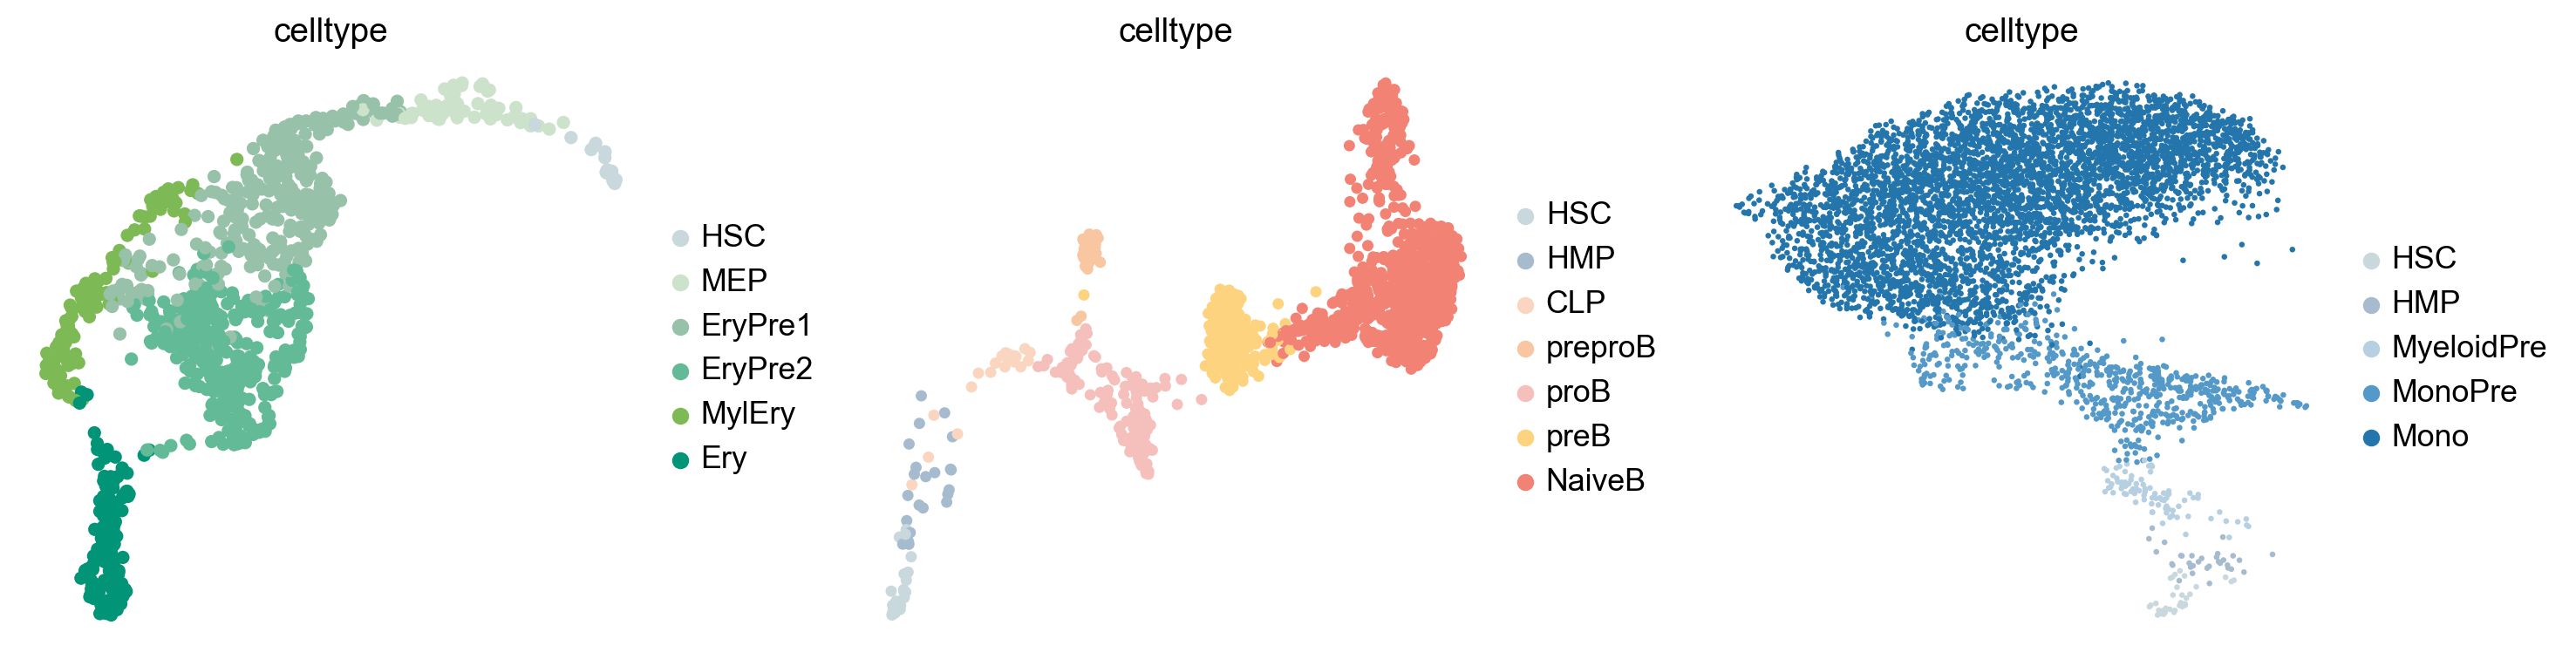

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.umap(gdataE["RNA"], color=["celltype"], ax=ax[0], show=False)
sc.pl.umap(gdataB["RNA"], color=["celltype"], ax=ax[1], show=False)
sc.pl.umap(gdataM["RNA"], color=["celltype"], ax=ax[2], show=False)
fig.tight_layout()

## Preprocessing(TF Activity)

In [18]:
from scmagnify.tools._gene_activity import get_acts

In [204]:
lineage_dict = {"E": gdataE, "M": gdataM, "B": gdataB}

all_tfs = set()
for gdata in lineage_dict.values():
    all_tfs.update(gdata.uns["filtered_network"]["TF"])
all_tfs = sorted(list(all_tfs))

for lineage_name, gdata in lineage_dict.items():

    gdata.filter(
        method = "quantile",
        param = 0.90,
        attri = "score",
        binarize = True,
        )

    net_df = pd.DataFrame({
        "source": gdata.uns["network"]["TF"],
        "target": gdata.uns["network"]["Target"],
        "weight": gdata.uns["network"]["score"],
    })
    net_df = net_df[gdata.uns["filtered_network"]["score"] == 1]

    adata_RNA = mdata["RNA"][gdata["GRN"].obs_names, :].copy()

    act_ad_mlm = get_acts(
        adata_RNA,
        method="mlm",
        net=net_df,
        use_raw=False
    )

    act_df_mlm = pd.DataFrame(
        act_ad_mlm.X,
        index=act_ad_mlm.obs_names,
        columns=act_ad_mlm.var_names
    )
    act_df_mlm = act_df_mlm.reindex(columns=all_tfs, fill_value=0)
    # act_df_mlm = act_df_mlm.loc[gdata["GRN"].obs_names, all_tfs]


    gdata["GRN"].layers["mlm_estimated"] = act_df_mlm.values

    act_ad_aucell = get_acts(
        adata_RNA,
        method="aucell",
        net=net_df,
        use_raw=False
    )

    act_df_aucell = pd.DataFrame(
        act_ad_aucell.X,
        index=act_ad_aucell.obs_names,
        columns=act_ad_aucell.var_names
    )

    act_df_aucell = act_df_aucell.reindex(columns=all_tfs, fill_value=0)
    
    gdata["GRN"].layers["aucell_estimated"] = act_df_aucell.values

                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 8610/86092 (0.10)    │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 4102/41013 (0.10)    │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 7915/79144 (0.10)    │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

In [205]:
adata_E = gdataE["GRN"]
adata_B = gdataB["GRN"]
adata_M = gdataM["GRN"]

adata_E.obs["lineage"] = "Ery"
adata_B.obs["lineage"] = "NaiveB"
adata_M.obs["lineage"] = "Mono"

adata_concat = ad.concat([adata_E, adata_B, adata_M], join="outer", axis=0)

In [206]:
adata_concat

AnnData object with n_obs × n_vars = 7791 × 105
    obs: 'sample', 'celltype', 'palantir_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'clusters_gradients', 'init_states_fwd', 'init_states_fwd_probs', 'n_counts', 'SEACell', 'pseudotime', 'lineage'
    obsm: 'T_fwd_umap', 'X_FDL', 'X_fate_simplex_fwd', 'X_pca', 'X_umap', 'cell_state_masks', 'cellrank_fate_probabilities', 'init_states_fwd_memberships', 'lineages_fwd', 'macrostates_fwd_memberships', 'mlm_estimate', 'mlm_pvals', 'schur_vectors_fwd'
    layers: 'aucell_estimated', 'mlm_estimated'

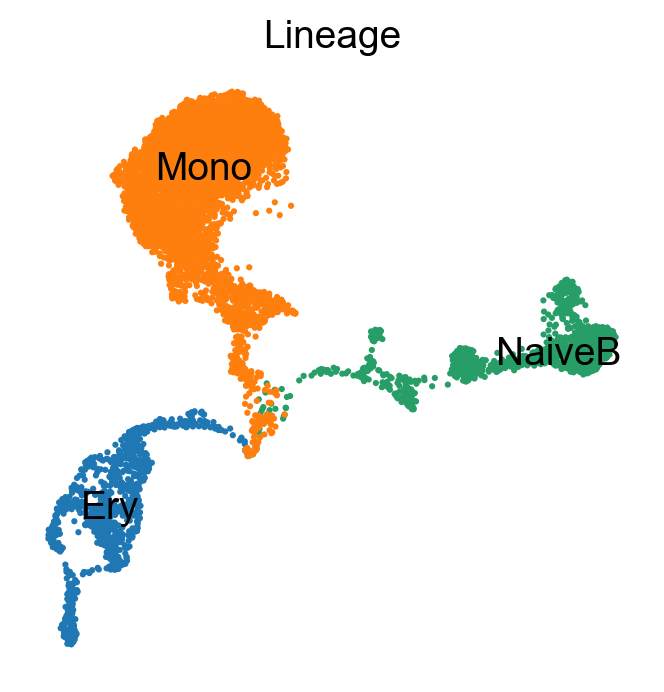

In [207]:
sc.pl.umap(adata_concat, color=["lineage"], frameon=False, legend_loc="on data", title="Lineage", size=20)

In [216]:
adata_concat.X = adata_concat.layers["mlm_estimated"].copy()

<Axes: >

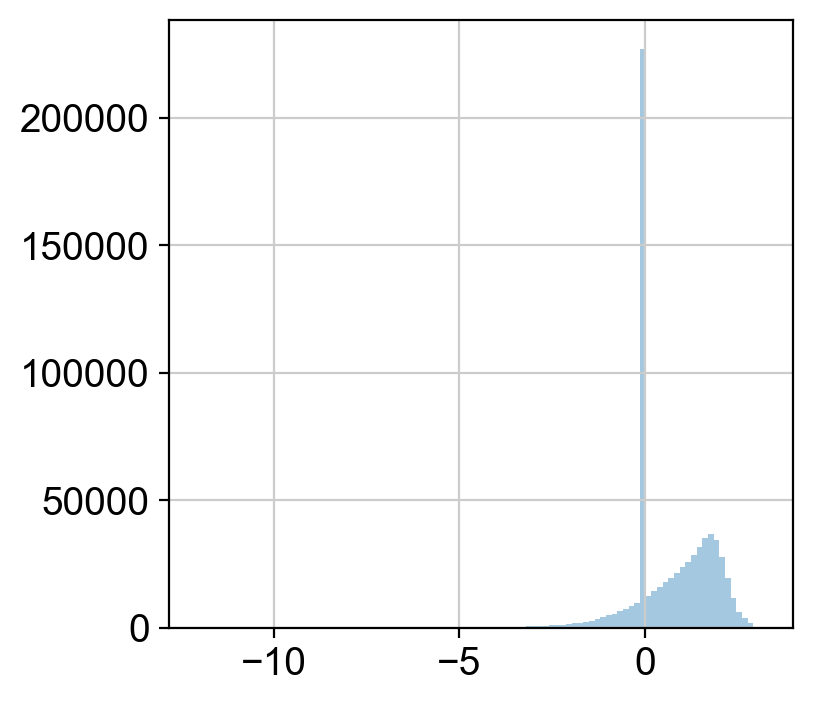

In [213]:
sc.pp.log1p(adata_concat)

<Axes: >

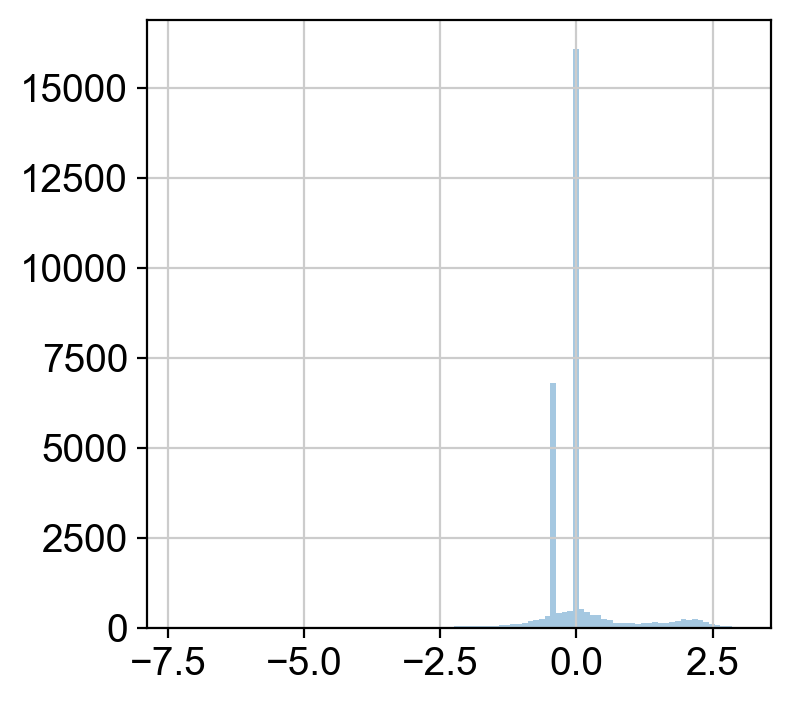

In [214]:
sc.pp.scale(adata_concat)

In [218]:
sc.tl.pca(adata_concat)
sc.pp.neighbors(adata_concat)

In [219]:
sc.tl.umap(adata_concat)

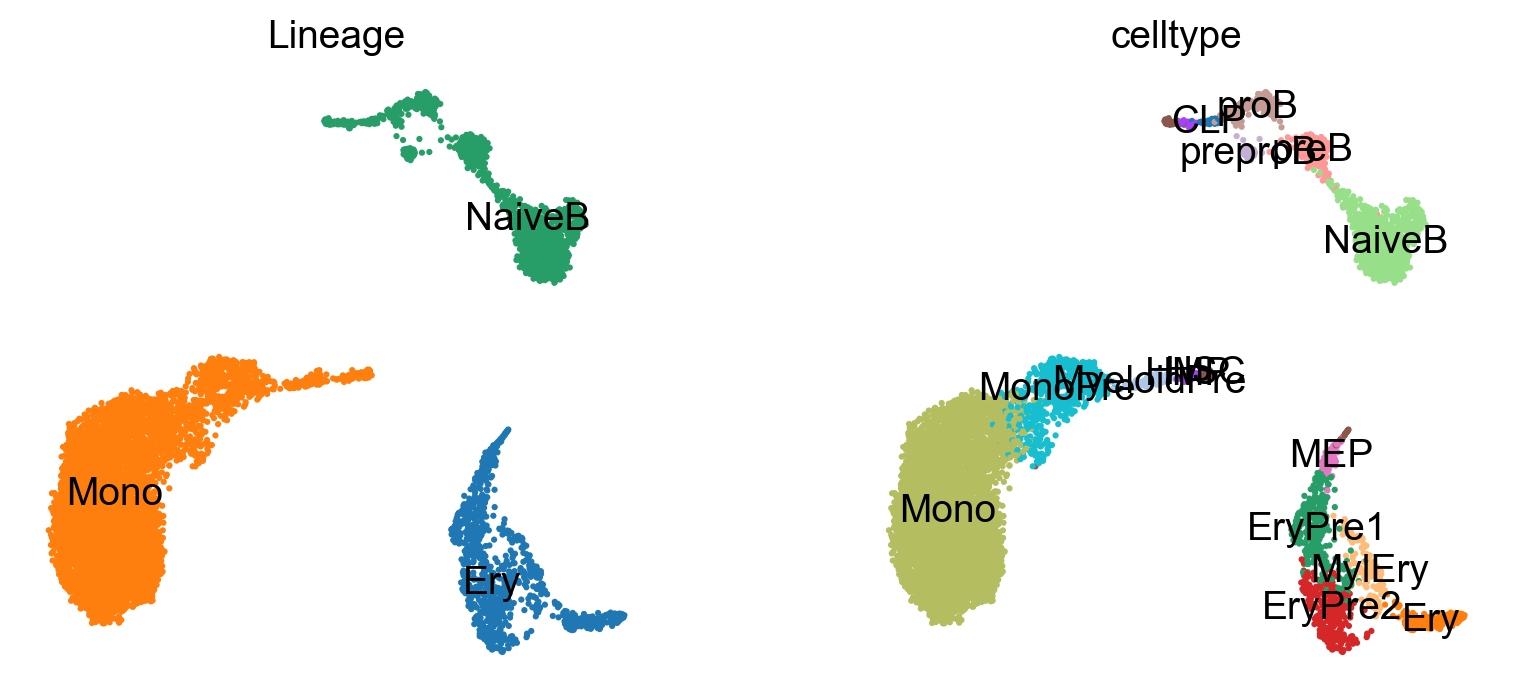

In [220]:
sc.pl.umap(adata_concat, color=["lineage", "celltype"], frameon=False, legend_loc="on data", title="Lineage", size=20)

### Prepare the data

In [20]:
lineage_dict = {"Ery": gdataE, "Mono": gdataM, "NaiveB": gdataB}
rna_df_dict = {}
mlm_df_dict = {}
aucell_df_dict = {}

stat_dict = {}

for lineage_name, gdata in lineage_dict.items():
    tf_genes = gdata["GRN"].var_names

    rna_df = pd.DataFrame(
        gdata["RNA"][:, tf_genes].X.A,
        index=gdata["RNA"].obs_names,
        columns=tf_genes
    )

    auc_df = pd.DataFrame(
        gdata["GRN"].layers["aucell_estimated"],
        index=gdata["RNA"].obs_names,
        columns=tf_genes
    )

    mlm_df = pd.DataFrame(
        gdata["GRN"].layers["mlm_estimated"],
        index=gdata["RNA"].obs_names,
        columns=tf_genes
    )

    stat_df = pd.DataFrame(index=tf_genes)
    stat_df["mean_mlm_estimated"] = mlm_df.mean()
    stat_df["mean_expression"] = rna_df.mean()
    stat_df["mean_aucell_estimated"] = auc_df.mean()

    rna_df_dict[lineage_name] = rna_df
    mlm_df_dict[lineage_name] = mlm_df
    aucell_df_dict[lineage_name] = auc_df

    stat_dict[lineage_name] = stat_df

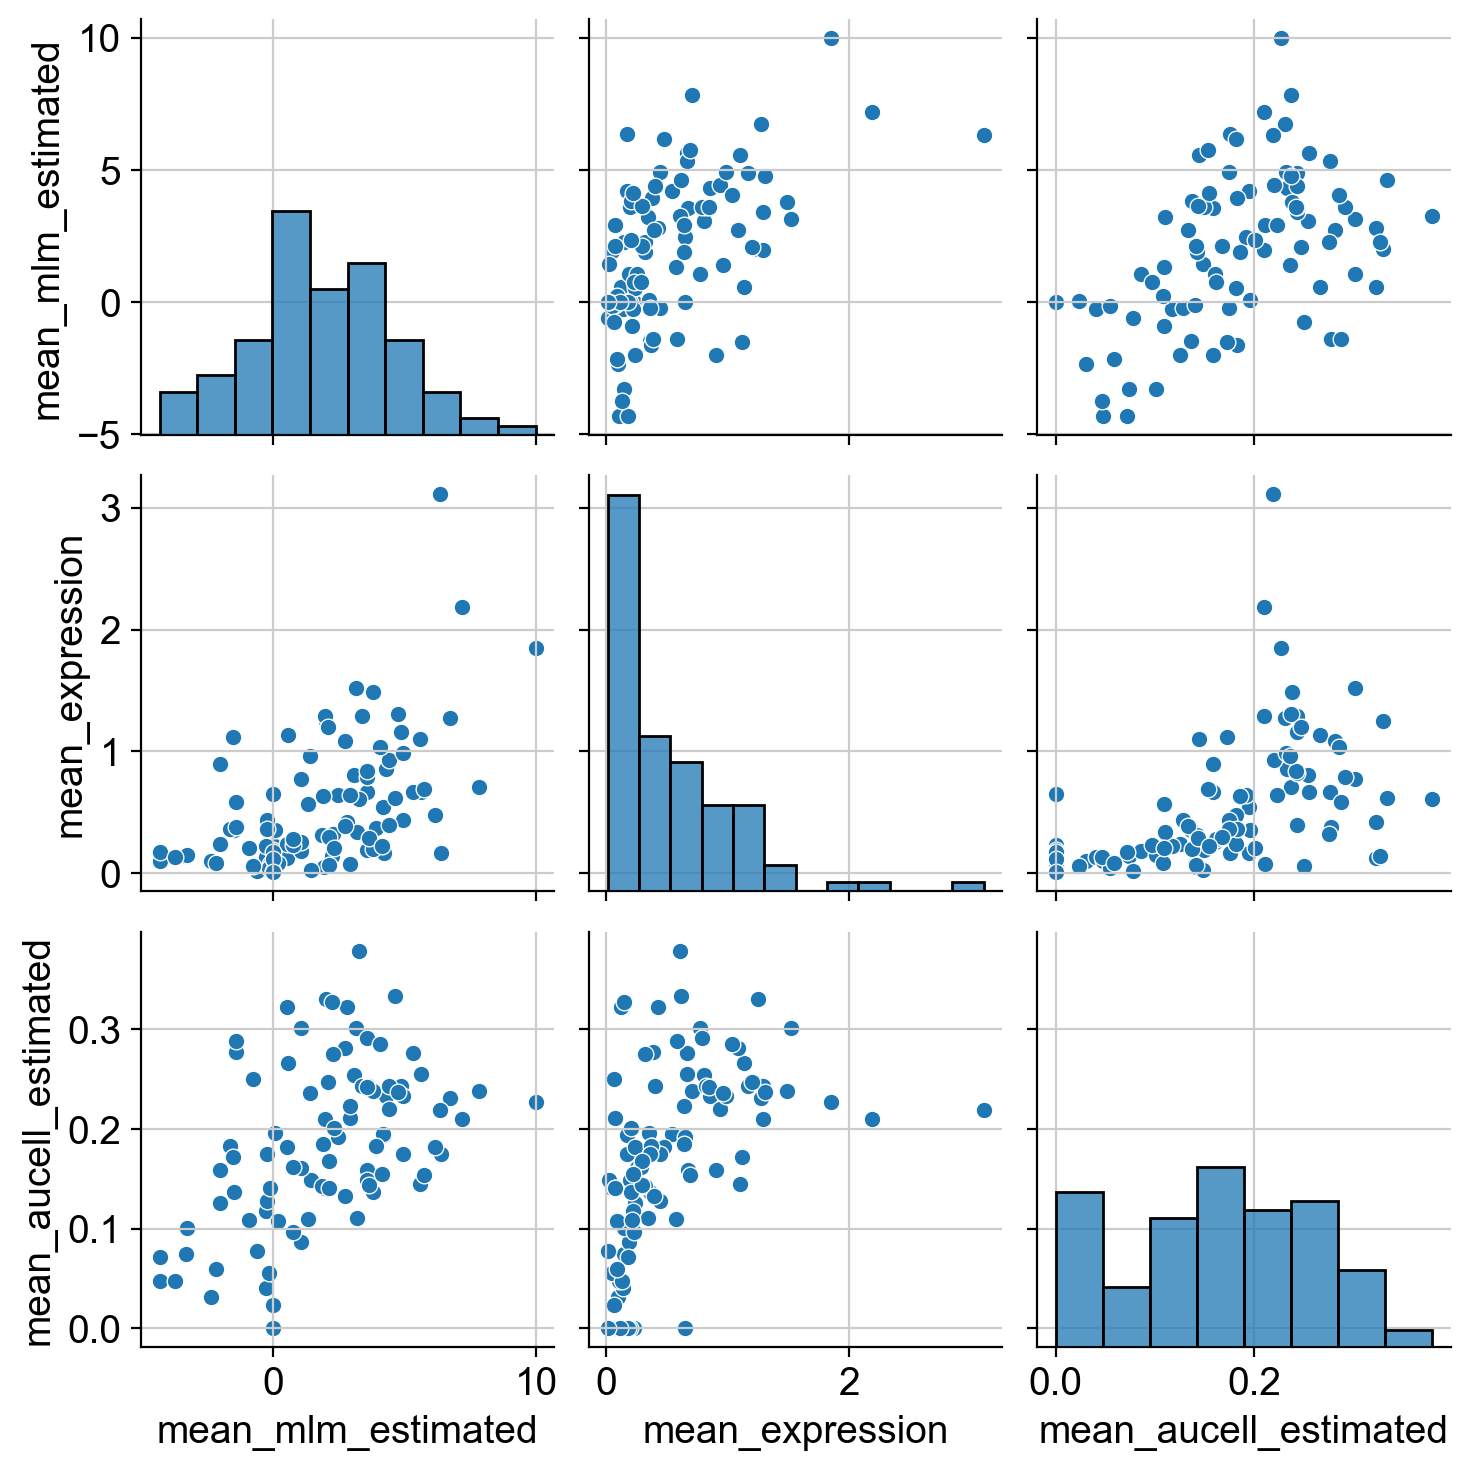

In [21]:
sns.pairplot(stat_dict["Ery"])
plt.show()

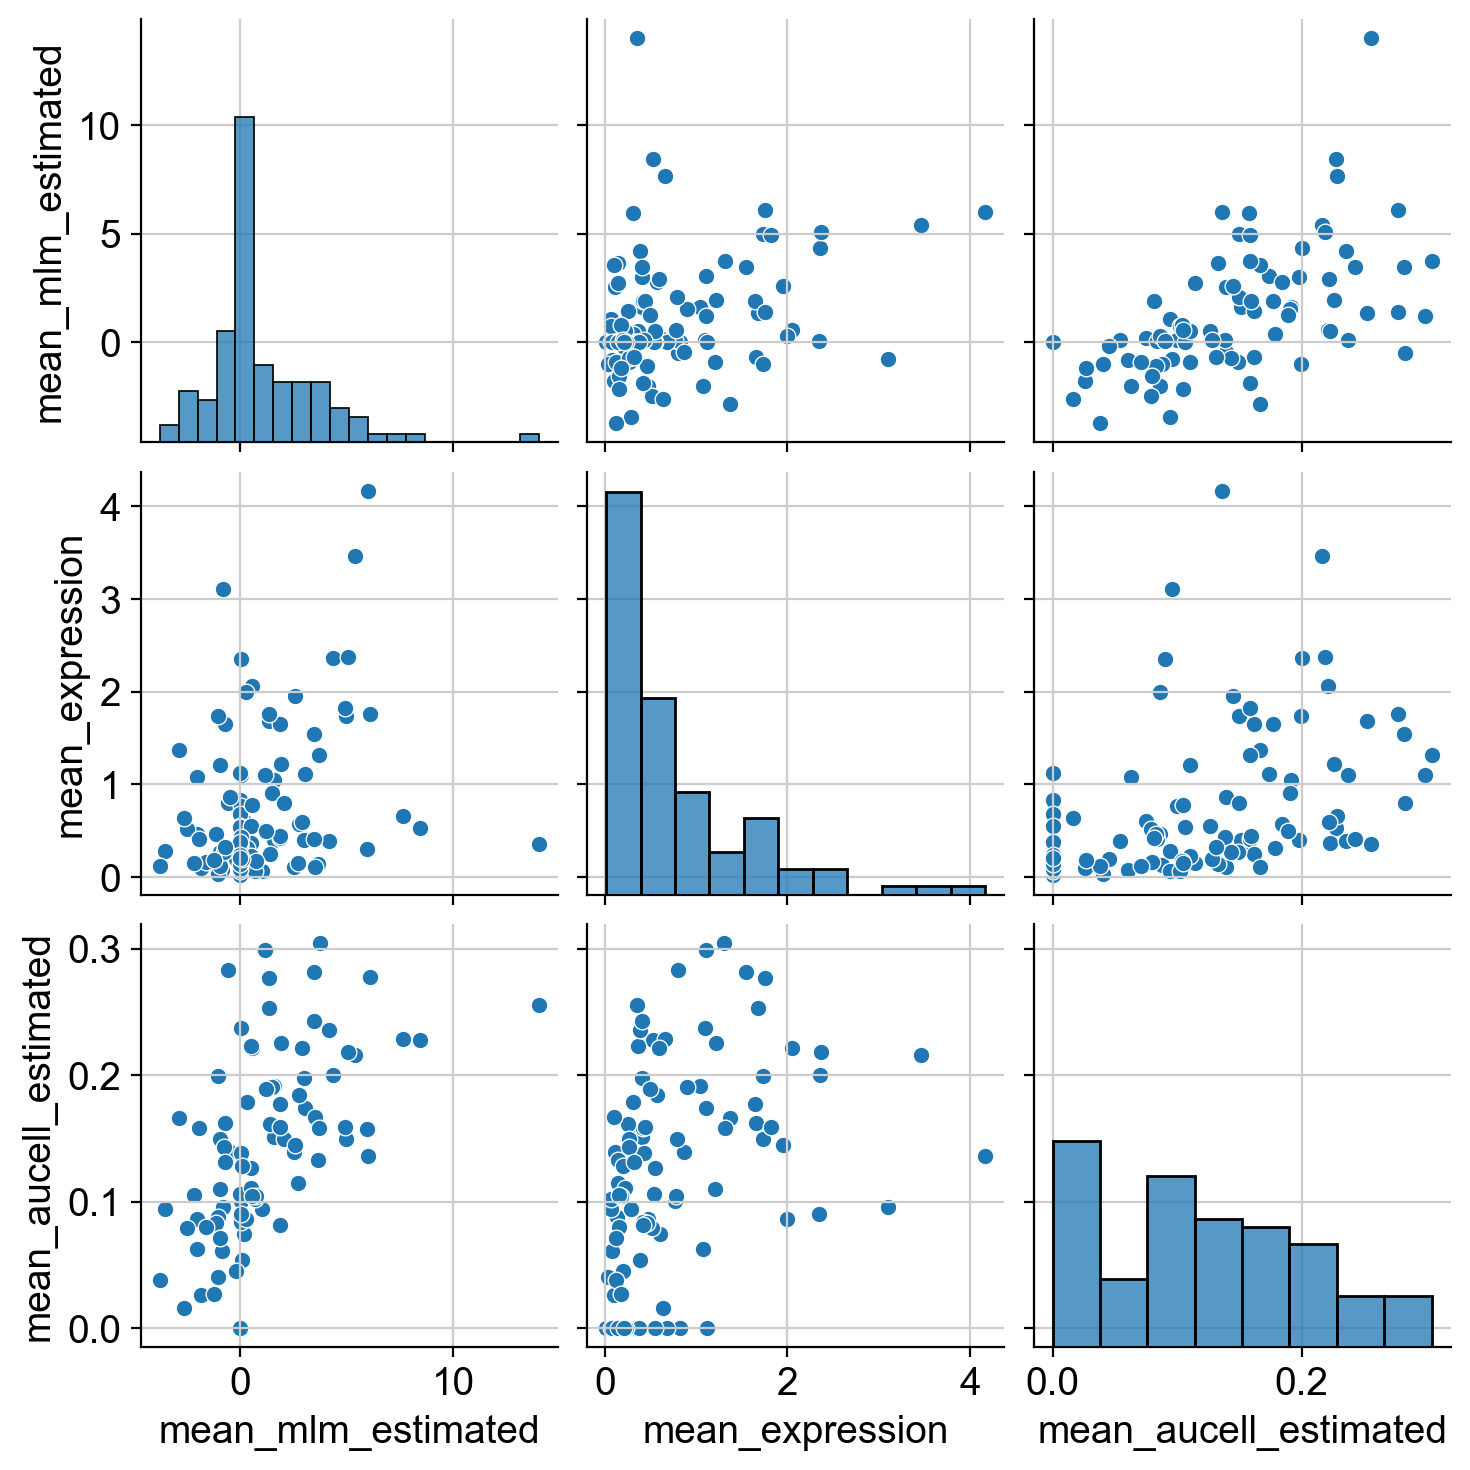

In [28]:
sns.pairplot(stat_dict["NaiveB"])
plt.show()

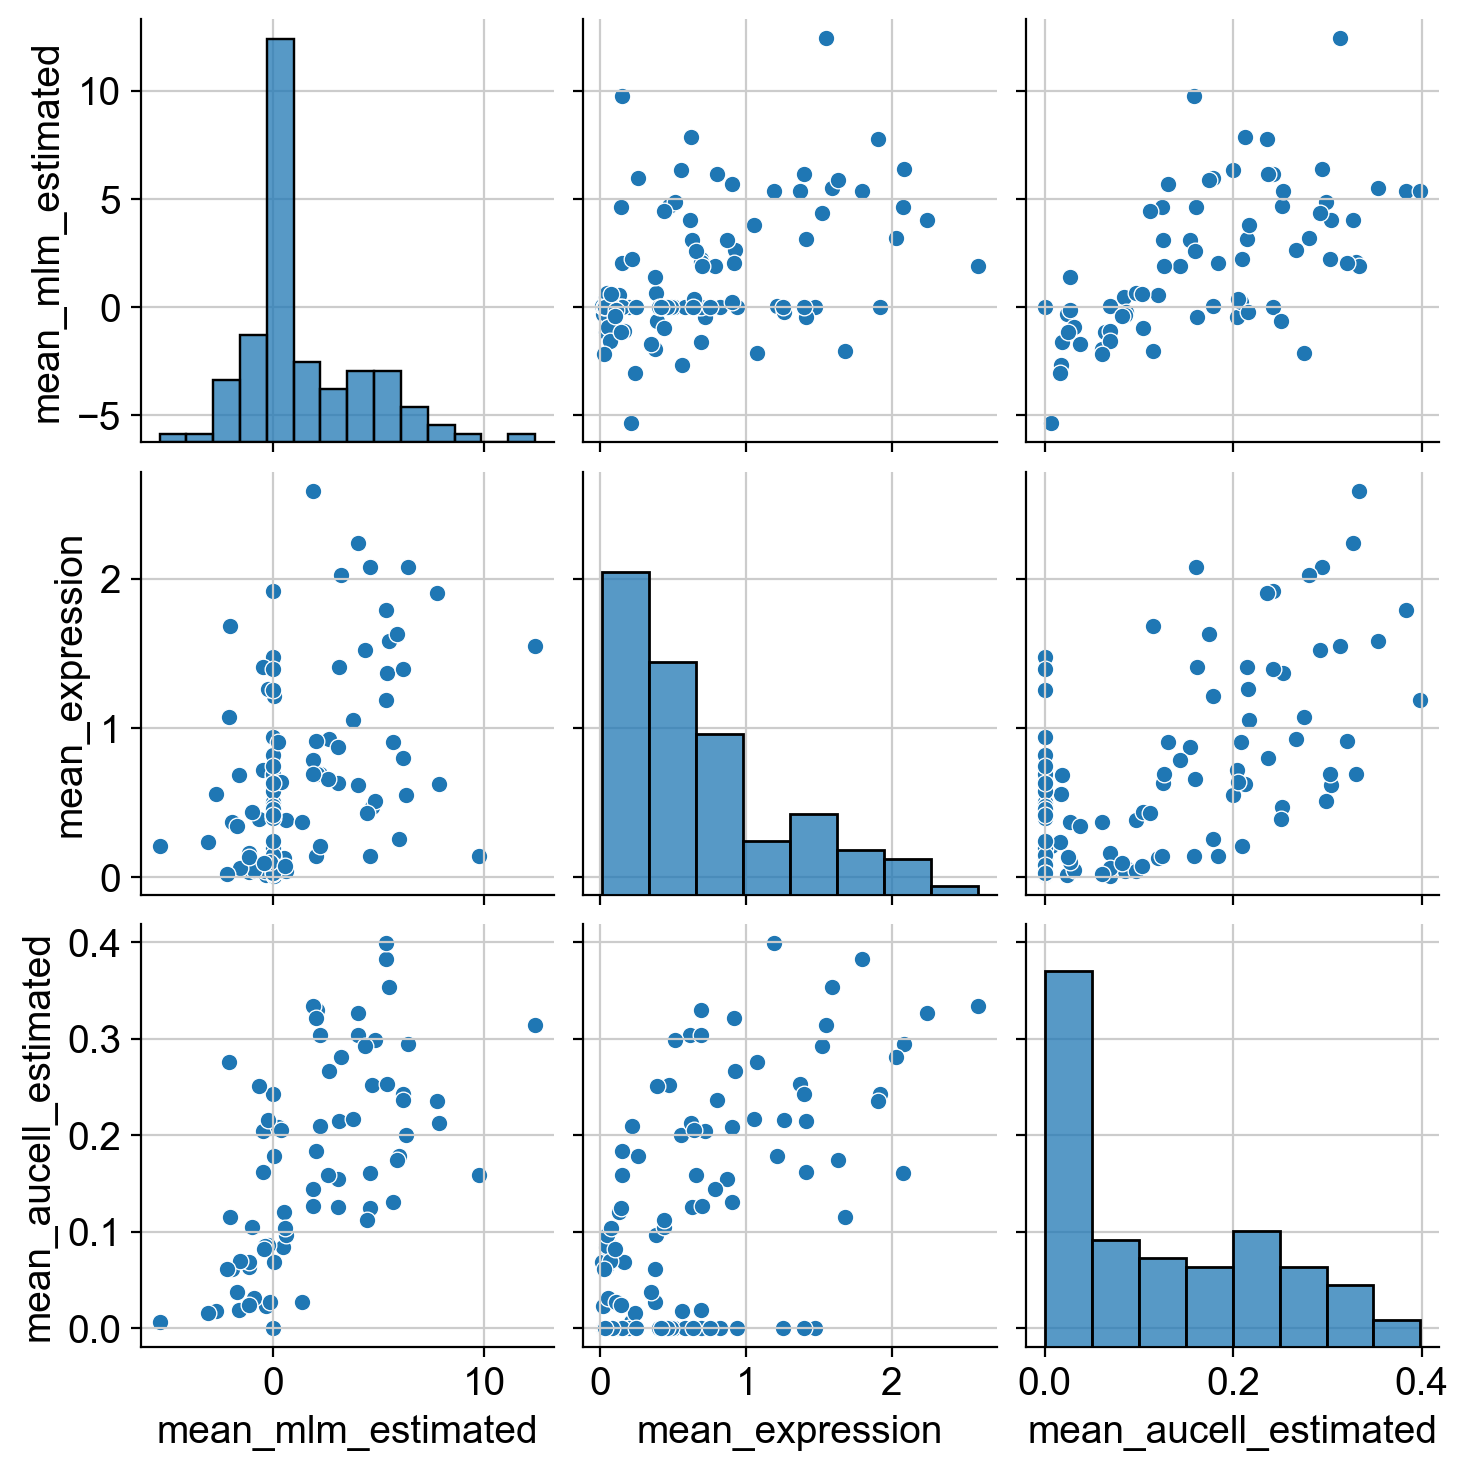

In [29]:
sns.pairplot(stat_dict["Mono"])
plt.show()

In [179]:
gdataE.write(os.path.join(settings.data_dir, "t-cell-depleted-bm_Ery_04.h5mu"))
gdataB.write(os.path.join(settings.data_dir, "t-cell-depleted-bm_NaiveB_04.h5mu"))
gdataM.write(os.path.join(settings.data_dir, "t-cell-depleted-bm_Mono_04.h5mu"))

### Differental Regulation

In [22]:
def log2fc(x1, x2, eps=1e-8):
    x1 = np.asarray(x1, dtype=np.float64)
    x2 = np.asarray(x2, dtype=np.float64)
    abs_x1 = x1 + eps
    abs_x2 = x2 + eps
    return np.log2(abs_x1 / abs_x2)

In [23]:
lineages = list(stat_dict.keys())
diff_dict = {}

for lineage in lineages:
    # 当前谱系的值
    current_df = stat_dict[lineage]
    
    # 取其余两个谱系
    others = [l for l in lineages if l != lineage]
    other_df_1, other_df_2 = stat_dict[others[0]], stat_dict[others[1]]
    
    # 计算对比组均值
    mean_other_mlm = (other_df_1["mean_mlm_estimated"] + other_df_2["mean_mlm_estimated"]) / 2
    mean_other_exp = (other_df_1["mean_expression"] + other_df_2["mean_expression"]) / 2
    
    # 计算 log2FC
    diff_df = pd.DataFrame(index=current_df.index)
    diff_df["diff_mlm_logfc"] = log2fc(current_df["mean_mlm_estimated"], mean_other_mlm)
    diff_df["diff_exp_logfc"] = log2fc(current_df["mean_expression"], mean_other_exp)
    diff_df["mean_diff_logfc"] = (diff_df["diff_mlm_logfc"] + diff_df["diff_exp_logfc"]) / 2
    
    # 存入字典
    diff_dict[lineage] = diff_df

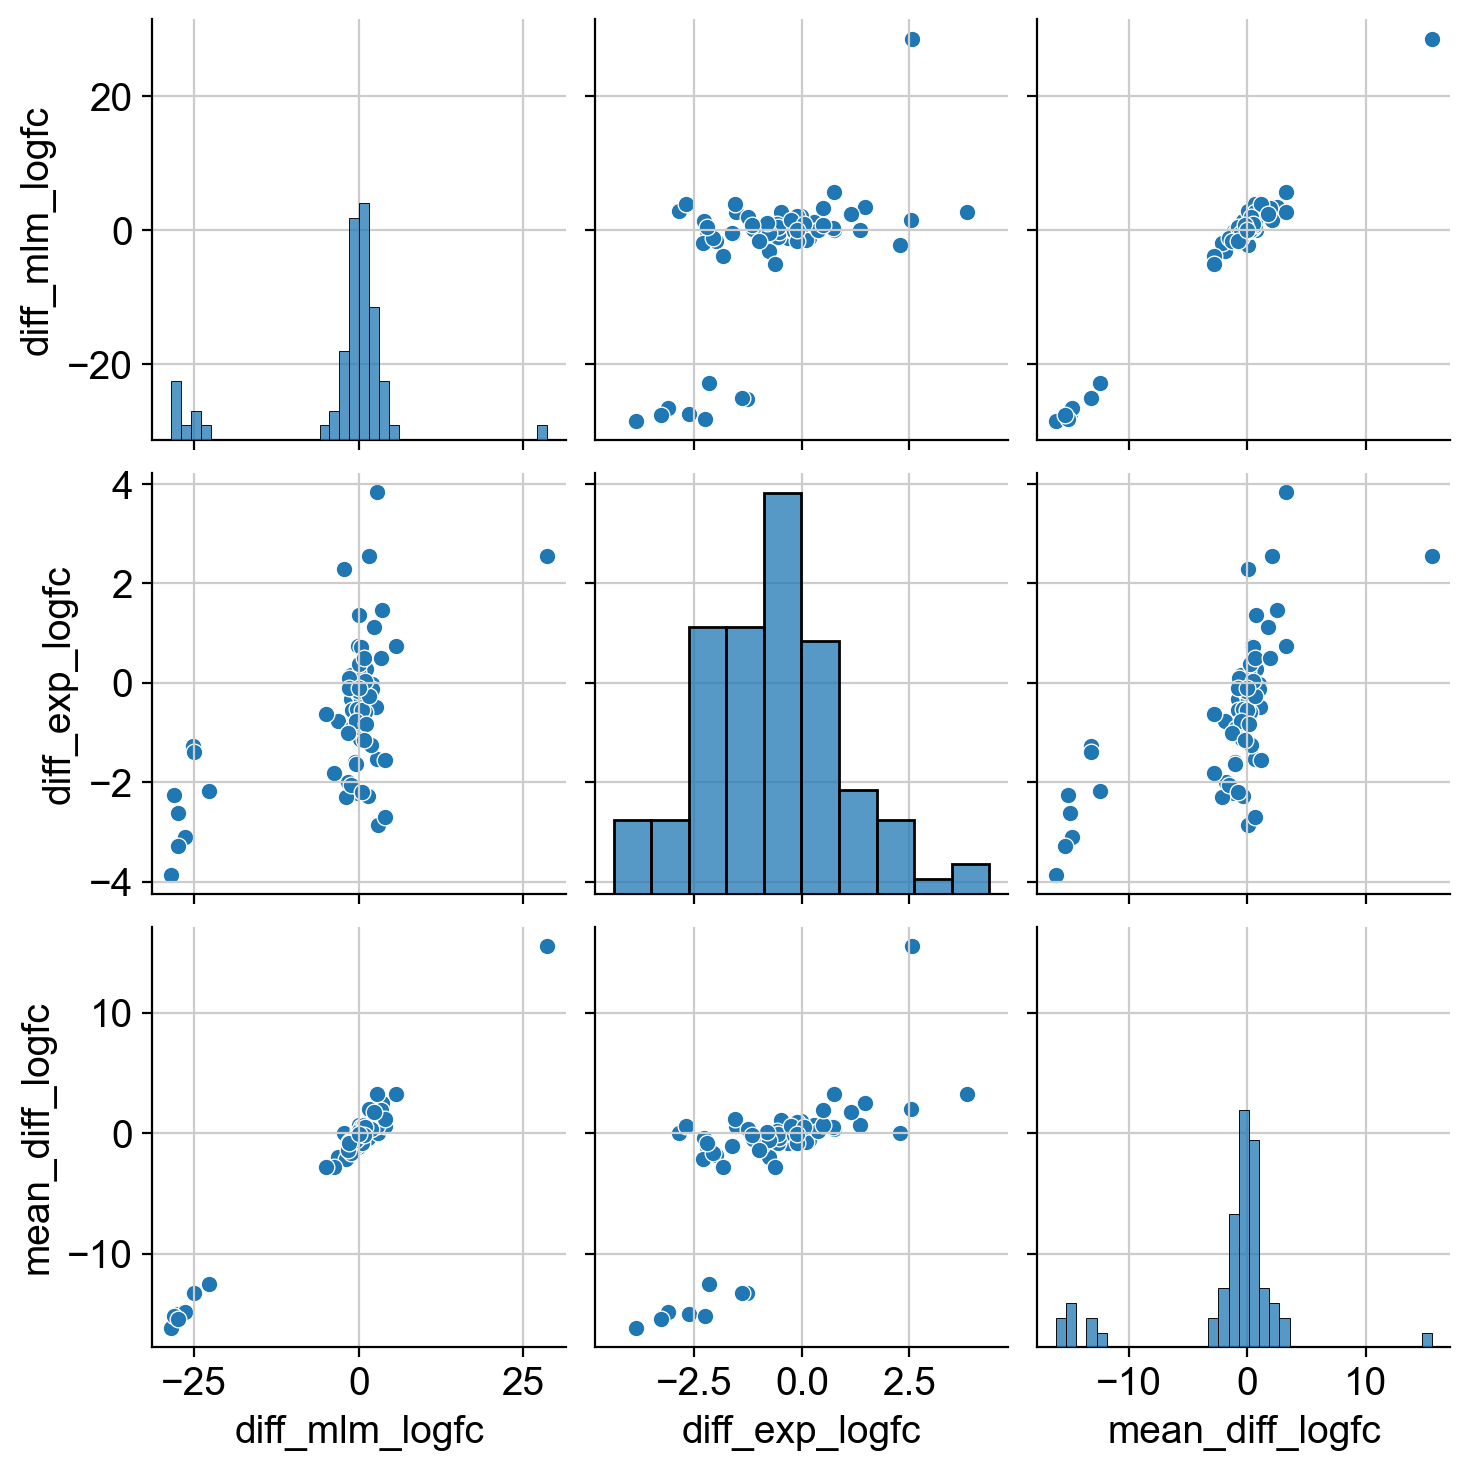

In [79]:
sns.pairplot(diff_dict["Ery"])


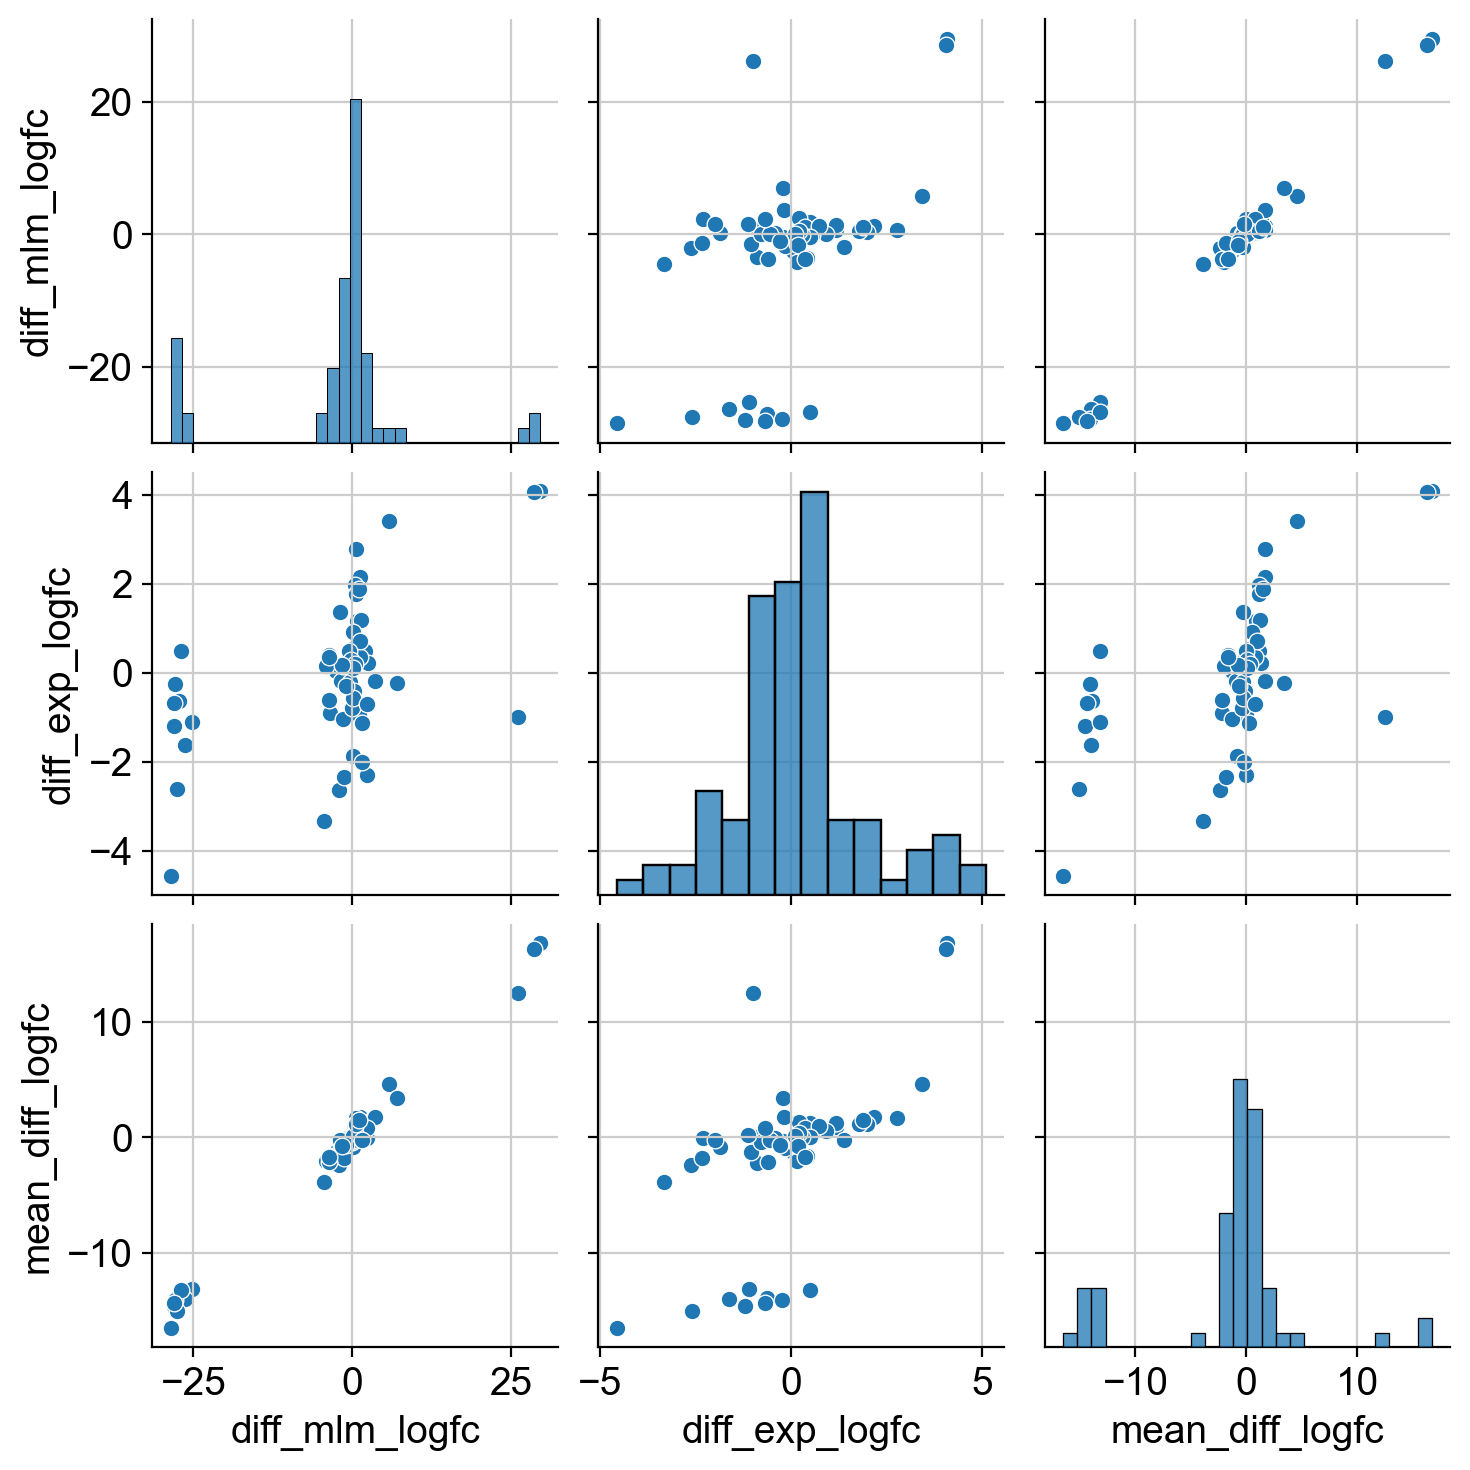

In [81]:
sns.pairplot(diff_dict["NaiveB"])

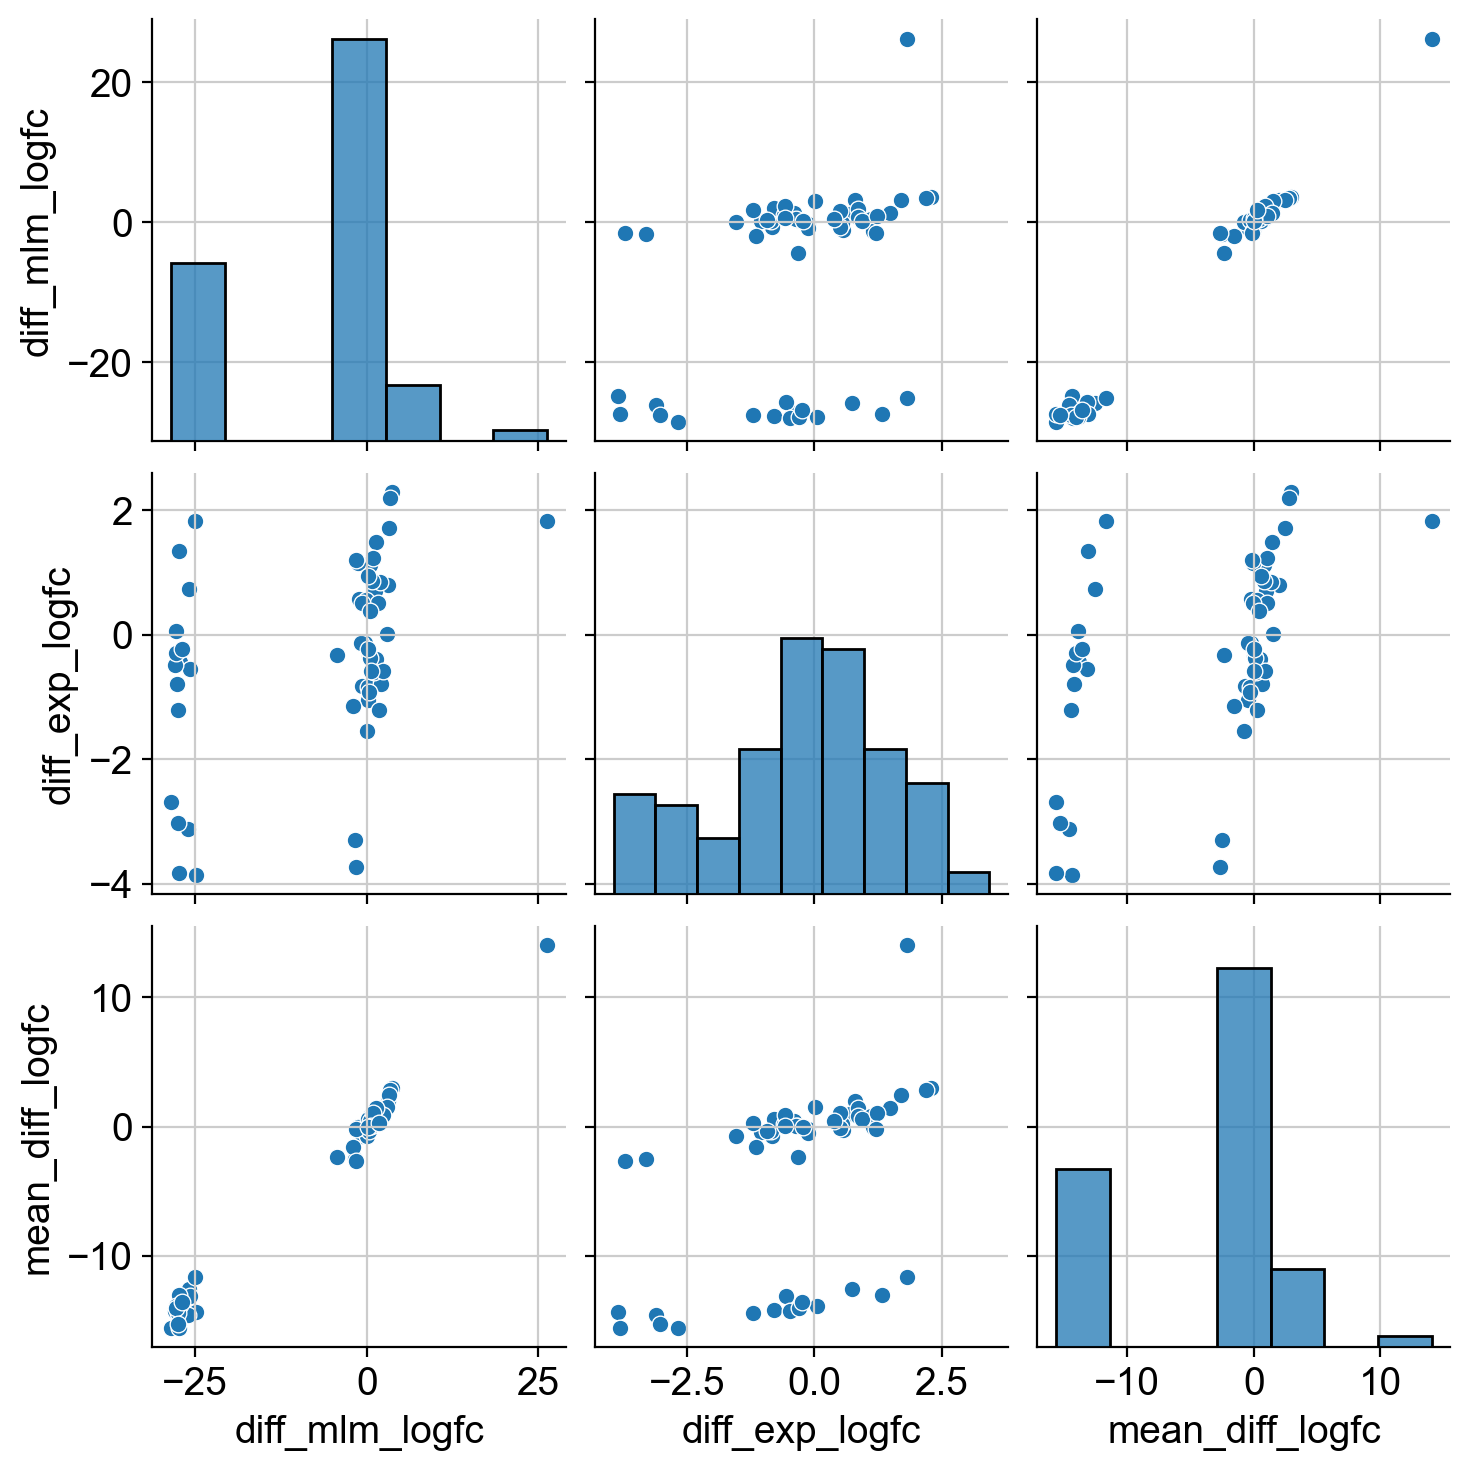

In [82]:
sns.pairplot(diff_dict["Mono"])

In [85]:
diff_dict["NaiveB"].sort_values(by = "mean_diff_logfc", ascending=False).tail(20)

,diff_mlm_logfc,diff_exp_logfc,mean_diff_logfc
NFATC2,NaN,1.531336,NaN
NFE2L2,NaN,-0.716442,NaN
NR3C1,NaN,0.302540,NaN
NR4A2,NaN,-1.080037,NaN
PAX5,NaN,5.036754,NaN
PBX3,NaN,0.008520,NaN
POU2F2,NaN,0.824861,NaN
RORA,NaN,-1.924416,NaN
SOX4,NaN,0.784645,NaN
SP3,NaN,-0.265404,NaN


## Regulation Specificity

In [24]:
from matplotlib.colors import LinearSegmentedColormap as lsc
kde_cmap = lsc.from_list( "", [(0., 'w'), (1, '#CCD7DC')], N=256)

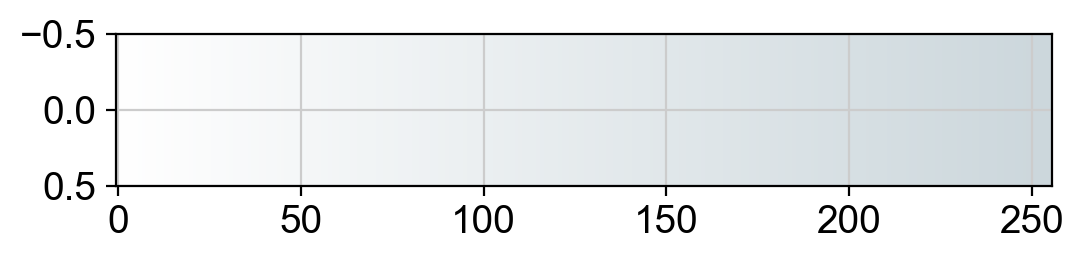

In [25]:
fig, ax = plt.subplots(figsize=(6, 1))
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=kde_cmap)

In [26]:
import scipy as sp
import numpy as np
import pandas as pd
import ternary
from ternary.helpers import (
    project_point,
    planar_to_coordinates,
    simplex_iterator
)
from matplotlib.colors import cnames, to_rgb
from matplotlib import collections, lines, pyplot as plt
import seaborn as sns
import colorsys
from typing import List


def ternary_kde(
    points,
    tax,
    n_levels=10,
    cmap="viridis",
    outline=False,
    bw_method='scott',
):
    # Project to 2D simplex
    simplex_points = np.apply_along_axis(project_point, 0, points)

    # Fit density model to 2D projection
    kde = sp.stats.gaussian_kde(simplex_points, bw_method=bw_method)

    # Evaluate density on triangular grid
    n = 100
    tri_grid = np.array(list(simplex_iterator(n))).T
    simplex_grid = np.apply_along_axis(project_point, 0, tri_grid)/n
    densities = kde(simplex_grid)
    levels = np.linspace(
        np.percentile(densities, 5), 
        np.percentile(densities, 95), 
        n_levels,
    ) 
    tax.ax.tricontourf(
        simplex_grid[0], simplex_grid[1], 
        densities, levels=levels, cmap=cmap,
        extend="both"
    )
    if outline:
        tax.ax.tricontour(
            simplex_grid[0], simplex_grid[1], 
            densities, levels=levels,
            colors=[[0,0,0,0.25]]+[[0,0,0,0.25]]*4,
            linewidths=[0.25]+[0.25]*4
        )


def format_tax(
    tax, 
    labels,
    fontsize,
    tick_width,
    boundary_width,
    pad,
):
    tax.gridlines(
        color="gray", lw=tick_width, linestyle='--', alpha=0.5, multiple=0.5
    )
    tax.ticks(
        axis='lbr', lw=tick_width, fontsize=fontsize, tick_formats='%.1f',
        offset=0.05, multiple=1.0,
    )
    tax.boundary(linewidth=boundary_width, zorder=4)
    tax.clear_matplotlib_ticks()
    tax.get_axes().axis('off')


def plot_ternary(
    points,
    cmap,
    titles,
    ax,
    n_pts: int = 1000,
):
    _, tax = ternary.figure(ax=ax)
    ternary_kde(
        points.T, 
        tax, 
        n_levels=9,
        cmap=cmap, 
        outline=True,
        bw_method=0.3,
    )
    idx = np.random.choice(points.shape[0], n_pts)
    tax.scatter(points[idx], s=20, lw=1, color="white", alpha=0.33)
    format_tax(
        tax=tax, 
        labels=titles,
        fontsize=12,
        tick_width=0.5,
        boundary_width=1,
        pad=2,
    )


def lighten_color(color, amount: float):
    # Lookup color in matplotlib named colors
    try:
        color = cnames[color]
    except:
        pass
    h, l, s = colorsys.rgb_to_hls(*to_rgb(color))
    color = colorsys.hls_to_rgb(h, 1 - amount * (1 - l), s)
    return color


def patch_violinplot(ax):
    children = ax.get_children()
    i = 0
    for n in range(0, len(children), 4):
        art = children[n: n+4]
        is_violin = len(art) == 4
        is_violin &= isinstance(art[0], collections.PolyCollection)
        is_violin &= all([isinstance(a, lines.Line2D) for a in art[1:]])
        if is_violin:
            violin, q1, q2, q3 = art
            c = violin.get_facecolor()
            if i%2==1: c = lighten_color(c, 0.5)
            violin.set_facecolor(c)
            violin.set_edgecolor(c)
            violin.set_linewidth(0.1)
            q2.set_linestyle('solid')
            q2.set_linewidth(0.5)
            q2.set_solid_capstyle('butt')
            for q in [q1, q3]:
                q.set_alpha(0)
            i += 1


def plot_kde(
    data: pd.DataFrame,
    row: str,
    row_order: List,
    **kwargs,
):
    # Update with default styles
    styles = dict(
        cut=0,
        common_norm=False, 
        density_norm='width',
        width=0.75,
        gap=0,
        split=True,
        fill=True,
        linewidth=0.5,
        legend=False,
        inner='quart',
    )
    kwargs.update(styles)

    # Plot KDEs
    grid = sns.FacetGrid(
        data,
        row=row,
        row_order=row_order,
        height=1.5,
        aspect=1.5,
        sharex=False,
        gridspec_kws=dict(hspace=0.5),
        despine=False,
    )
    fig = grid.map_dataframe(sns.violinplot, **kwargs)

    # Formatting
    for ax in fig.axes.flat:
        patch_violinplot(ax)
        ax.set_title('')
        ax.set_xlim(0, 1)
        ax.yaxis.set_visible(False)
        ax.spines[['top', 'left', 'right']].set_visible(False)
        ax.set_xlabel(kwargs['x'])

In [27]:
def normalize_ternary_data(df, cols):
    """将三列归一化为三个比例，加和为1"""
    ternary_array = df[cols].values
    row_sums = ternary_array.sum(axis=1, keepdims=True)
    normed = ternary_array / (row_sums + 1e-10)
    return normed

def ternary_from_tf_df(tf_df, lineage_cols, ax=None, cmap="viridis", n_pts=1000):
    # 归一化为 ternary 三元组
    normed_points = normalize_ternary_data(tf_df, lineage_cols)

    # 画图
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    plot_ternary(
        points=normed_points,
        cmap=cmap,
        titles=lineage_cols,
        ax=ax,
        n_pts=min(len(normed_points), n_pts),
    )
    return ax


In [28]:
def ternary_from_tf_df2(
    tf_df,
    lineage_cols,
    ax=None,
    label=None,  # int, None, or list
    lineage_cmap=None,
    n_pts=1000,
    font_scale=1.0,
    noise_epsilon=0,
):
    import matplotlib.colors as mcolors
    from adjustText import adjust_text

    if lineage_cmap is None:
        lineage_cmap={"Ery": "#367D00",
                    "NaiveB": "#C86800",
                    "Mono": "#265795"}

    # Step 1: Normalize + small perturbation
    normed_points = normalize_ternary_data(tf_df, lineage_cols).copy()
    perturb = np.zeros_like(normed_points)
    perturb += (normed_points == 0) * np.random.uniform(noise_epsilon, 2 * noise_epsilon, normed_points.shape)
    perturb -= (normed_points == 1) * np.random.uniform(noise_epsilon, 2 * noise_epsilon, normed_points.shape)
    normed_points += perturb
    normed_points = np.clip(normed_points, 0, None)
    normed_points /= normed_points.sum(axis=1, keepdims=True)

    # Step 2: Assign main_lineage and specificity_score
    main_lineage_idx = normed_points.argmax(axis=1)
    tf_df["_ternary_x"] = normed_points[:, 0]
    tf_df["_ternary_y"] = normed_points[:, 1]
    tf_df["_ternary_z"] = normed_points[:, 2]
    tf_df["main_lineage"] = [lineage_cols[i] for i in main_lineage_idx]
    tf_df["specificity_score"] = normed_points.max(axis=1) - normed_points.mean(axis=1)

    # Step 3: Draw ternary background
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    plot_ternary(
        points=normed_points,
        cmap=kde_cmap,  # Base background
        titles=lineage_cols,
        ax=ax,
        n_pts=min(len(normed_points), n_pts),
    )

    # Step 4: Add colored scatter
    simplex_points = np.apply_along_axis(project_point, 1, normed_points)
    norm_scores = tf_df["specificity_score"].values
    norm_scores = (norm_scores - norm_scores.min()) / (norm_scores.max() - norm_scores.min() + 1e-6)

    point_colors = []
    # for i, row in tf_df.iterrows():
    #     base_color = lineage_cmap.get(row["main_lineage"], "#cccccc")
    #     rgb = mcolors.to_rgb(base_color)
    #     color = colorsys.rgb_to_hls(*rgb)
    #     darkened = colorsys.hls_to_rgb(color[0], 0.75 - 0.5 * norm_scores[i], color[2])
    #     point_colors.append(darkened)

    gray_rgb = np.array([0.6, 0.6, 0.6])  # 比默认灰浅一点，看起来更柔和
    for idx, (i, row) in enumerate(tf_df.iterrows()):
        base_color = lineage_cmap.get(row["main_lineage"], "#cccccc")
        base_rgb = np.array(mcolors.to_rgb(base_color))
        score = norm_scores[idx]
        mixed_rgb = gray_rgb * (1 - score) + base_rgb * score
        point_colors.append(tuple(mixed_rgb))

    ax.scatter(simplex_points[:, 0], simplex_points[:, 1],
               s=25, lw=0.2, edgecolors="black", color=point_colors, alpha=1)

    # Step 5: Add labels
    texts = []
    if isinstance(label, int):
        for lineage in lineage_cols:
            df_top = (
                tf_df[tf_df["main_lineage"] == lineage]
                .sort_values("specificity_score", ascending=False)
                .head(label)
            )
            for gene, row in df_top.iterrows():
                x0, y0 = project_point([row["_ternary_x"], row["_ternary_y"], row["_ternary_z"]])
                label_x = x0 + 0.03
                label_y = y0 + 0.03
                text = ax.text(
                    label_x, label_y, gene,
                    fontsize=8 * font_scale, color="black",
                    fontstyle="italic",
                    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=1)
                )
                texts.append(text)
                # ax.plot([x0, label_x], [y0, label_y], color="black", linestyle="--", linewidth=0.5)
                
    elif isinstance(label, list):
        df_top = tf_df.loc[tf_df.index.intersection(label)]
        for gene, row in df_top.iterrows():
            x0, y0 = project_point([row["_ternary_x"], row["_ternary_y"], row["_ternary_z"]])
            label_x = x0 + 0.03
            label_y = y0 + 0.03
            text = ax.text(
                label_x, label_y, gene,
                fontsize=8 * font_scale, color="black",
                fontstyle="italic",
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=1)
            )
            texts.append(text)
            ax.plot([x0, label_x], [y0, label_y], color="black", linestyle="--", linewidth=1)

    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0))

    return ax


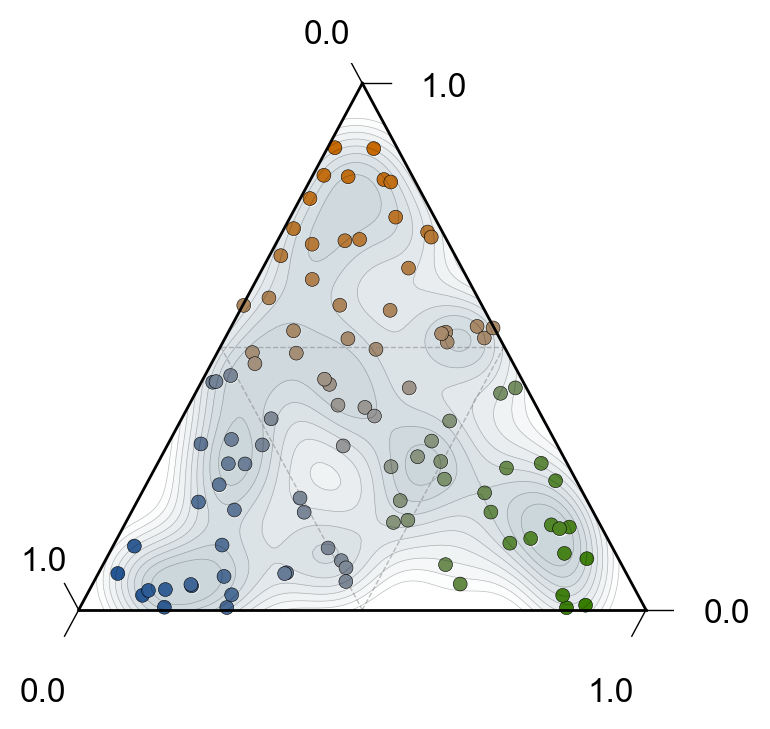

In [395]:
import matplotlib.pyplot as plt

def generate_random_ternary(n=100, seed=42):
    np.random.seed(seed)
    raw = np.random.dirichlet([1, 1, 1], size=n)  # 从 Dirichlet 分布中采样
    return raw  # shape: (n, 3)

points = generate_random_ternary(100)

points_df = pd.DataFrame(points, columns=['Ery', 'NaiveB', 'Mono'])

ax = ternary_from_tf_df2(points_df, 
                         ['Ery', 'NaiveB', 'Mono'], 
                         n_pts=1000, 
                         lineage_cmap={"Ery": "#367D00",
                                       "NaiveB": "#C86800",
                                       "Mono": "#265795"},)
plt.show()


In [29]:
exp_df_norm = pd.DataFrame(index = gdataE["GRN"].var_names)
exp_df_norm["Ery"] = stat_dict["Ery"]["mean_expression"]
exp_df_norm["NaiveB"] = stat_dict["NaiveB"]["mean_expression"]
exp_df_norm["Mono"] =  stat_dict["Mono"]["mean_expression"]
exp_df_norm = exp_df_norm.div(exp_df_norm.sum(axis=1), axis=0)

In [30]:
exp_df_norm

,Ery,NaiveB,Mono
AHR,0.111024,0.178593,0.710383
ARID5B,0.033784,0.690304,0.275913
ATF2,0.377250,0.339201,0.283549
BACH1,0.227224,0.306921,0.465855
BACH2,0.051373,0.903026,0.045601
...,...,...,...
ZEB1,0.316265,0.647410,0.036325
ZKSCAN1,0.303198,0.341910,0.354892
ZNF121,0.476232,0.293830,0.229939
ZNF331,0.275154,0.436540,0.288306


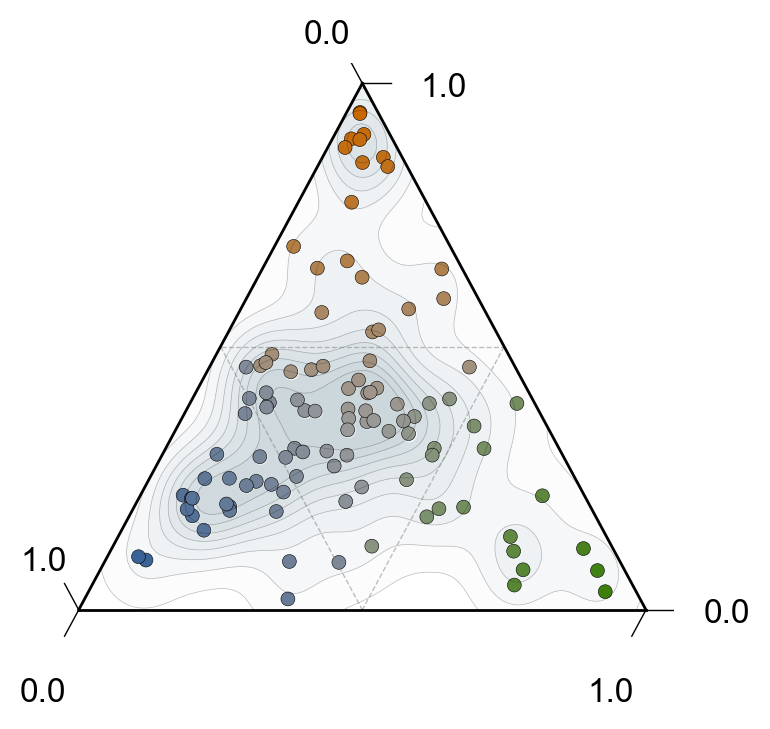

In [32]:
ax = ternary_from_tf_df2(exp_df_norm, 
                         ['Ery', 'NaiveB', 'Mono'], 
                         n_pts=1000, 
                         lineage_cmap={"Ery": "#367D00",
                                       "NaiveB": "#C86800",
                                       "Mono": "#265795"},)
plt.show()

In [33]:
mlm_df_norm = pd.DataFrame(index = gdataE["GRN"].var_names)
mlm_df_norm["Ery"] = np.abs(stat_dict["Ery"]["mean_mlm_estimated"])
mlm_df_norm["NaiveB"] = np.abs(stat_dict["NaiveB"]["mean_mlm_estimated"])
mlm_df_norm["Mono"] =  np.abs(stat_dict["Mono"]["mean_mlm_estimated"])
mlm_df_norm = mlm_df_norm.div(mlm_df_norm.sum(axis=1), axis=0)
mlm_df_norm.dropna(inplace=True)

# mlm_df_zscore = mlm_df_norm.sub(mlm_df_norm.mean(axis=1), axis=0)
# mlm_df_zscore = mlm_df_zscore.div(mlm_df_zscore.std(axis=1), axis=0)

# offset = mlm_df_norm.min(axis=1)  # 每行的最小值
# mlm_df_shifted = mlm_df_norm.sub(offset, axis=0)  # 整体向上平移
# mlm_df_normed = mlm_df_shifted.div(mlm_df_shifted.sum(axis=1), axis=0)

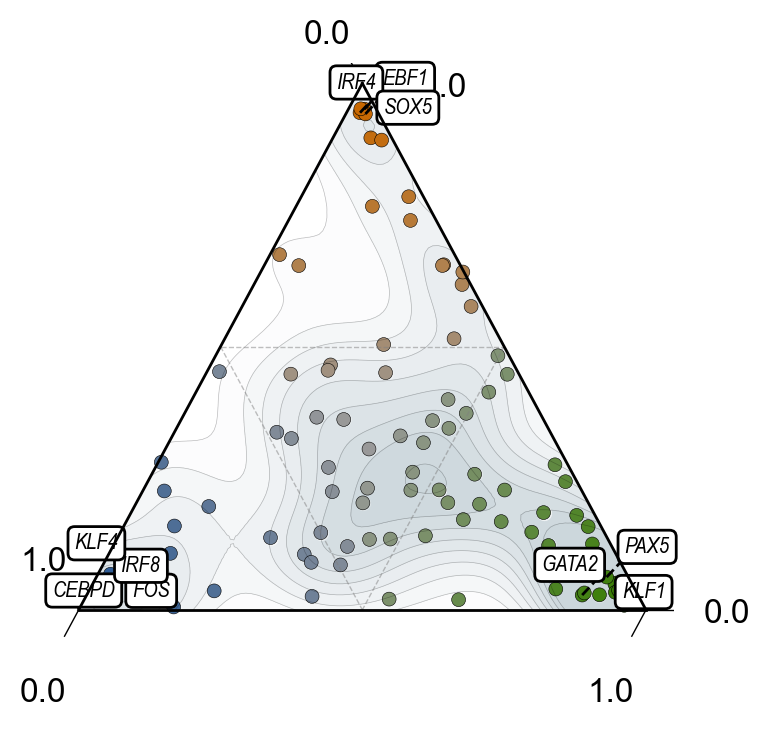

In [34]:
ax = ternary_from_tf_df2(mlm_df_norm, 
                         ["Ery", "NaiveB", "Mono"], 
                         n_pts=1000, label=["EBF1", "IRF4", "SOX5", "SPI1", "KLF4", "FOS", "CEBPD", "IRF8", "KLF1", "GATA2", "PAX5"], 
                         noise_epsilon=0.02)
plt.show()

In [35]:
mlm_exp_df_norm = (mlm_df_norm[["Ery", "NaiveB", "Mono"]] + exp_df_norm[["Ery", "NaiveB", "Mono"]]) / 2

In [36]:
mlm_exp_df_norm.dropna(inplace=True)

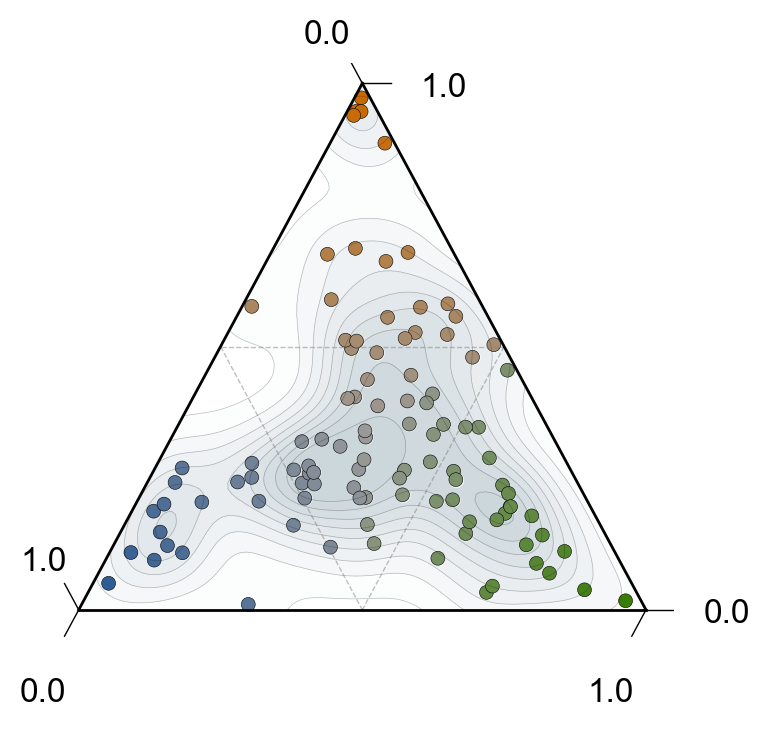

In [37]:
ax = ternary_from_tf_df2(mlm_exp_df_norm, 
                         ["Ery", "NaiveB", "Mono"], 
                         n_pts=1000, 
                         noise_epsilon=0.02)
plt.savefig("./figures/tf_target_specificity_ternary.pdf", bbox_inches='tight', dpi=300)

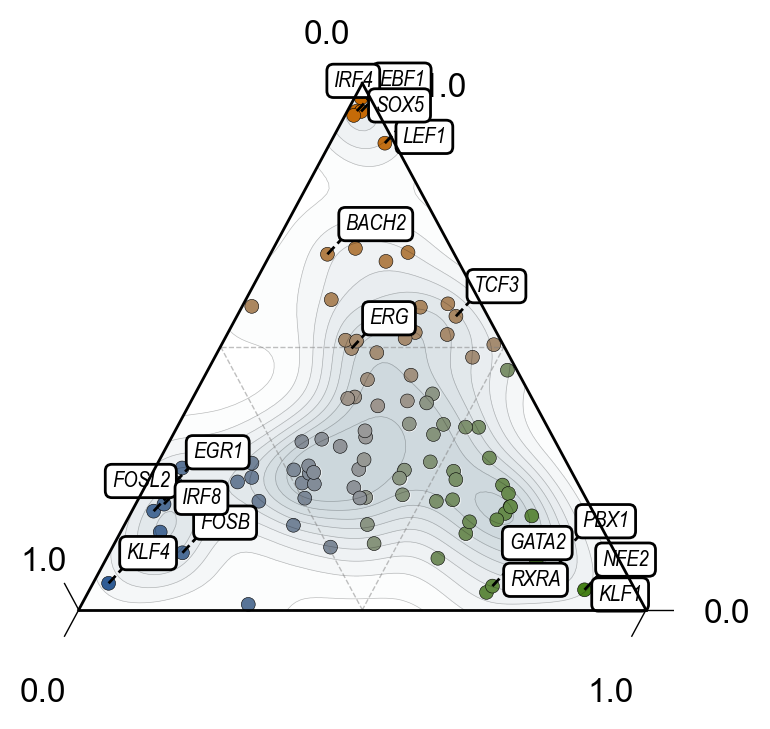

In [342]:
ax = ternary_from_tf_df2(mlm_exp_df_norm, 
                         ["Ery", "NaiveB", "Mono"], 
                         n_pts=1000, label=[tf for tfs in tf_dict.values() for tf in tfs], 
                         noise_epsilon=0.02)
plt.show()

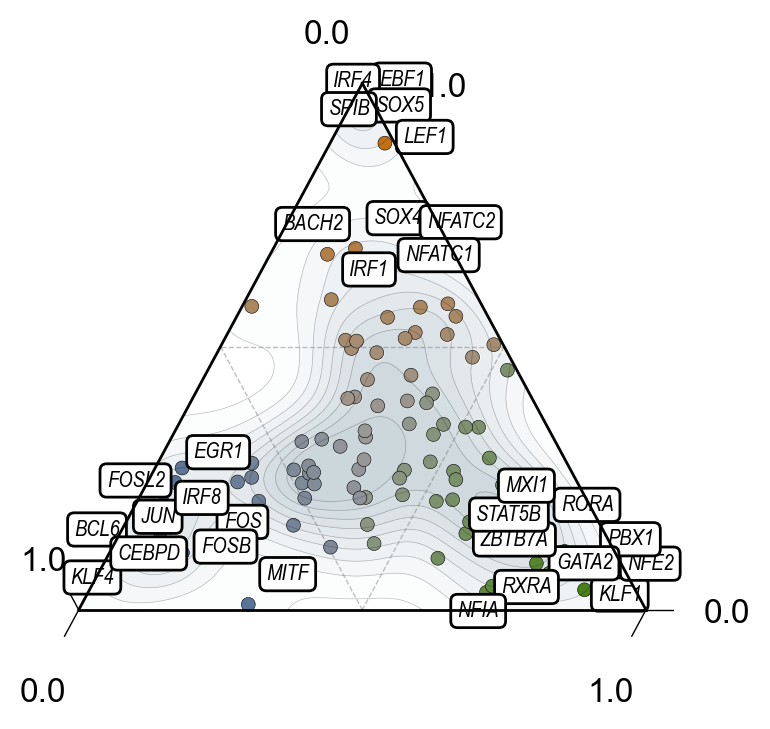

In [298]:
ax = ternary_from_tf_df2(mlm_exp_df_norm, 
                         ["Ery", "NaiveB", "Mono"], 
                         n_pts=1000, label=10, 
                         noise_epsilon=0.02)
plt.show()

### Stacked bar

In [38]:
target_genes = mdata["RNA"][:, mdata["RNA"].var.significant_genes].var_names

In [39]:
lineage_dict = {"Ery": gdataE, "Mono": gdataM, "NaiveB": gdataB}
target_genes = mdata["RNA"][:, mdata["RNA"].var.significant_genes].var_names
rna_target_df = pd.DataFrame(index = target_genes, columns = lineage_dict.keys())

for lineage_name, gdata in lineage_dict.items():
    lin_cells = gdata["RNA"].obs_names
    
    rna_df = pd.DataFrame(
        mdata["RNA"][gdata["RNA"].obs_names, target_genes].layers["log1p_norm"].A,
        index=gdata["RNA"].obs_names,
        columns=target_genes
    )

    rna_target_df[lineage_name] = rna_df.mean(axis=0)

In [40]:
rna_target_df

,Ery,Mono,NaiveB
NADK,0.143768,0.372814,0.194183
KCNAB2,0.084047,0.527278,0.189850
RPL22,1.067991,1.010944,0.865104
CAMTA1,0.430256,0.425828,0.491781
RERE,1.428336,1.152208,2.077666
...,...,...,...
MT-ND4L,2.562649,2.610472,2.276965
MT-ND4,4.176109,4.312686,3.921028
MT-ND5,3.577939,3.697538,2.938240
MT-ND6,0.766805,0.871704,0.496319


In [41]:
lineages = list(stat_dict.keys())
diff_target_df = pd.DataFrame(index = target_genes, columns = lineages)

for lineage in lineages:

    current_df = rna_target_df[lineage]
    others = [l for l in lineages if l != lineage]
    other_df_1, other_df_2 = rna_target_df[others[0]], rna_target_df[others[1]]

    mean_other_exp = (other_df_1 + other_df_2) / 2

    diff_target_df[lineage] = log2fc(current_df, mean_other_exp)

In [42]:
diff_target_df

,Ery,Mono,NaiveB
NADK,-0.979598,1.141643,-0.411582
KCNAB2,-2.092968,1.944932,-0.687079
RPL22,0.187203,0.064791,-0.264900
CAMTA1,-0.092683,-0.114552,0.200261
RERE,-0.177143,-0.605425,0.687289
...,...,...,...
MT-ND4L,0.068558,0.109419,-0.183923
MT-ND4,0.020616,0.091175,-0.114328
MT-ND5,0.108863,0.182539,-0.308090
MT-ND6,0.164839,0.464914,-0.723043


In [43]:
rna_target_df_div = rna_target_df.div(rna_target_df.sum(axis=1), axis=0)

In [44]:
rna_target_df_div

,Ery,Mono,NaiveB
NADK,0.202272,0.524525,0.273203
KCNAB2,0.104904,0.658131,0.236964
RPL22,0.362764,0.343387,0.293849
CAMTA1,0.319213,0.315928,0.364859
RERE,0.306628,0.247350,0.446022
...,...,...,...
MT-ND4L,0.343976,0.350395,0.305629
MT-ND4,0.336516,0.347522,0.315962
MT-ND5,0.350307,0.362017,0.287676
MT-ND6,0.359188,0.408325,0.232487


In [45]:
def classify_lineage(row, threshold=0.4, margin=0.2):
    vals = row.values
    max_idx = np.argmax(vals)
    max_val = vals[max_idx]
    sorted_vals = np.sort(vals)
    second_max_val = sorted_vals[-2]

    if max_val > threshold and (max_val - second_max_val) > margin:
        return row.index[max_idx]
    else:
        return "None"

In [46]:
rna_target_df_div = rna_target_df.div(rna_target_df.sum(axis=1), axis=0)
rna_target_df_div["lineage"] = rna_target_df_div.apply(classify_lineage, axis=1)
rna_target_df_div["lineage"].value_counts()

lineage
None      1623
Mono       669
Ery        561
NaiveB     428
Name: count, dtype: int64

In [47]:
def classify_lineage_by_logfc(row, min_diff=0.2, min_fc=0.4):
    max_val = row.max()
    median_val = row.median()
    if (max_val - median_val < min_diff) or (max_val < min_fc):
        return "None"
    return row.idxmax()

In [48]:
diff_target_df["lineage"] = diff_target_df.apply(classify_lineage_by_logfc, axis=1)
diff_target_df["lineage"].value_counts()

lineage
Mono      1032
Ery        914
NaiveB     726
None       609
Name: count, dtype: int64

In [49]:
# target_lineage = rna_target_df_div["lineage"]
target_lineage = diff_target_df["lineage"]

In [50]:
tf_lineage_count_dict = {}

for lineage, gdata in lineage_dict.items():
    edge_df = gdata.uns["filtered_network"][gdata.uns["filtered_network"]["score"] == 1][["TF", "Target"]].copy()
    edge_df = edge_df[edge_df["Target"].isin(target_lineage.index)]
    edge_df = edge_df.merge(target_lineage, left_on="Target", right_index=True, how="left")

    tf_lineage_count = edge_df.groupby(['TF', 'lineage']).size().unstack(fill_value=0)

    tf_lineage_count_dict[lineage] = tf_lineage_count

In [51]:
tf_dict = {
    "NaiveB": ["ERG",  "IRF4", "BACH2", "TCF3", "EBF1", "SOX5", "LEF1"],
    "Mono": ["IRF8", "KLF4", "FOSL2", "FOSB", "EGR1", "MYB", "JUN", "RUNX2"],
    "Ery": ["KLF1", "GATA2", "PBX1", "NFE2", "RXRA"]
}

In [52]:
# 初始化结果容器
final_data = {
    'TF': [],
    'Ery': [],
    'Mono': [],
    'NaiveB': [],
    'None': []
}

# 遍历每个谱系
for lineage, tf_list in tf_dict.items():
    df = tf_lineage_count_dict[lineage]
    temp_data = {
        'TF': [],
        'Ery': [],
        'Mono': [],
        'NaiveB': [],
        'None': [],
        'Total': []
    }

    # 收集该 lineage 下的 TF 信息
    for tf in tf_list:
        if tf in df.index:
            ery = df.loc[tf, 'Ery']
            mono = df.loc[tf, 'Mono']
            naiveb = df.loc[tf, 'NaiveB']
            none = df.loc[tf, 'None']
        else:
            ery = mono = naiveb = none = 0

        temp_data['TF'].append(tf)
        temp_data['Ery'].append(ery)
        temp_data['Mono'].append(mono)
        temp_data['NaiveB'].append(naiveb)
        temp_data['None'].append(none)
        temp_data['Total'].append(ery + mono + naiveb + none)

    # 构建临时 DataFrame 并按 Total 排序
    temp_df = pd.DataFrame(temp_data)
    temp_df = temp_df.sort_values(by='Total', ascending=False)

    # 将排序结果添加到总的结果中
    for col in ['TF', 'Ery', 'Mono', 'NaiveB', 'None']:
        final_data[col].extend(temp_df[col].tolist())

# 构建最终 DataFrame
df = pd.DataFrame(final_data)
print(df)

       TF  Ery  Mono  NaiveB  None
0     ERG  105   151     244    97
1   BACH2  129   122      91   102
2    IRF4   68    95     185    69
3    LEF1   51    47     103    33
4    SOX5   30    34      97    24
5    TCF3   24    34     103    22
6    EBF1   50    67      44    21
7    EGR1   49   124      31    32
8   RUNX2   53    43      37    56
9     JUN    7    85      17     9
10    MYB   33    31      17    18
11   FOSB    6    32       1    14
12   KLF4    2    27       1     2
13   IRF8    1    18       6     3
14  FOSL2    0    23       1     0
15   KLF1   51    17       8    34
16   PBX1   52     7       5    16
17   NFE2   49     6       0    10
18  GATA2   37     7      15     3
19   RXRA   35     3       2    12


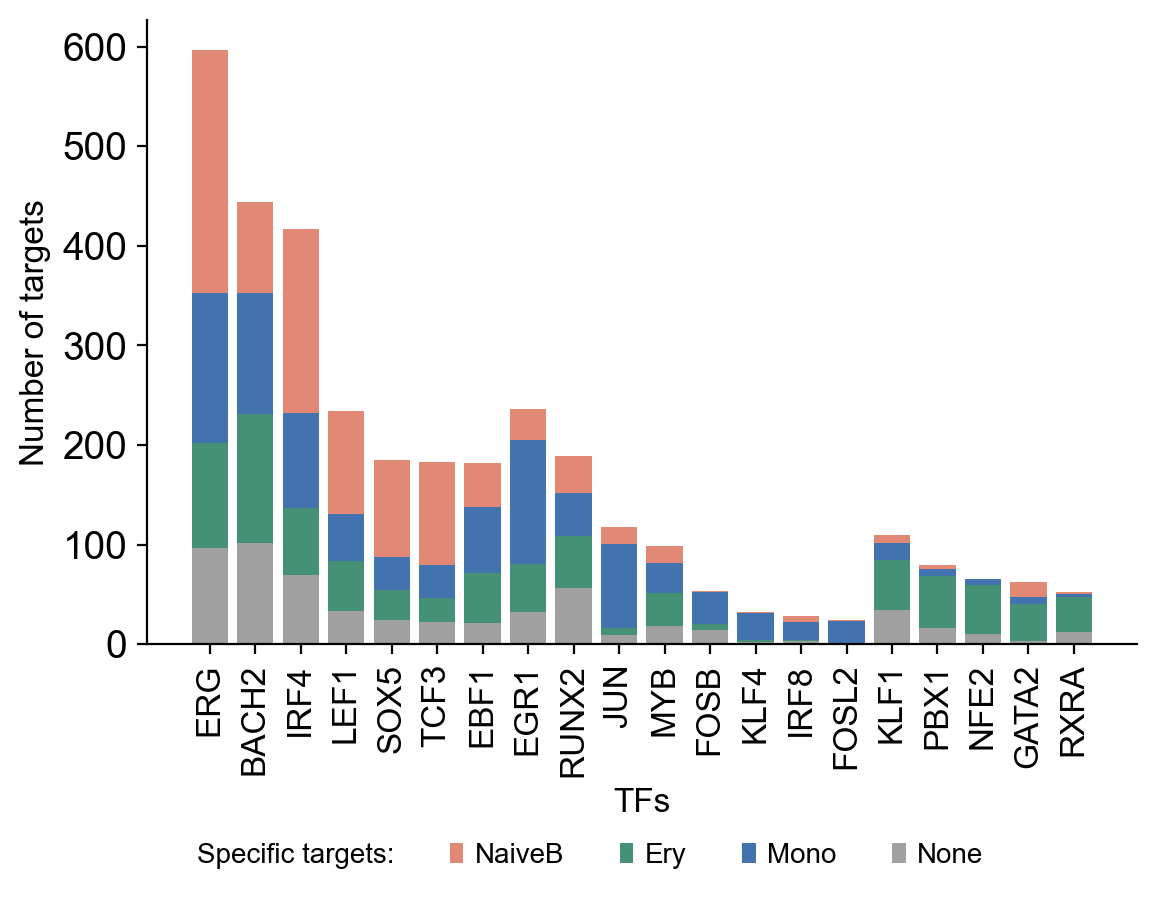

In [54]:
plt.rcParams["grid.alpha"] = 0

# Define the colors for each category as seen in the image
colors = {
    "Ery": "#459175",
    "NaiveB": "#E18974",
    "Mono": "#4273AE",
    'None': '#a0a0a0'    # Gray
}

# Create the figure and axes
fig, ax = plt.subplots(figsize=(6, 7)) # Adjust figure size as needed

# Plot the stacked bars
bottom = np.zeros(len(df))
for col in ['None', 'Ery', 'Mono',  'NaiveB']: # Order of stacking from bottom to top
    ax.bar(df['TF'], df[col], label=col, color=colors[col], bottom=bottom, width=0.8) # Adjust width as needed
    bottom += df[col]

# Set labels and title
ax.set_xlabel('TFs', fontsize=12)
ax.set_ylabel('Number of targets', fontsize=12)
# ax.set_title('Transcription Factor Target Specificity', fontsize=14) # No explicit title in the image

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=12)

# Add legend
# Create a custom legend handle for 'Specific targets:' if needed, but the original image just uses the text.
# The `handles` and `labels` arguments for `legend` allow for more control.
# Let's try to replicate the legend appearance as closely as possible.
legend_labels = ['Specific targets:', 'NaiveB', 'Ery', 'Mono', 'None']
legend_handles = [
    plt.Line2D([0], [0], color='none', label='Specific targets:'), # Placeholder for the bold text
    plt.Rectangle((0, 0), 1, 1, fc=colors['NaiveB']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['Ery']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['Mono']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['None'])
]

legend = ax.legend(legend_handles, legend_labels, loc='lower left', bbox_to_anchor=(0.0, -0.4), ncol=5, frameon=False, fontsize=10)

# Set the 'Specific targets:' label to bold
# For the legend, directly making one part bold is tricky with standard legend.
# A common workaround is to add it as separate text or post-process the legend text.
# For simplicity in initial code, let's just use regular text.
# If strict replication of "Specific targets: **N.t.**" is needed, it would require more advanced text formatting or annotations.
# Based on the image, "Specific targets:" is just text, and the target types are directly after it.

# Adjust layout to prevent labels from being cut off
plt.tight_layout(rect=[0, 0.2, 1, 1]) # Adjust rect to make space for the legend at the bottom

# Remove top and right spines to match the image style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add 'e' label at the top left corner as in the image
# ax.text(-0.07, 1.03, 'e', transform=ax.transAxes, fontsize=20, va='top', ha='right')

plt.show()

# Save the figure if needed
fig.savefig("./figures/tf_target_specificity_stacked_bar.pdf", bbox_inches='tight', dpi=300)

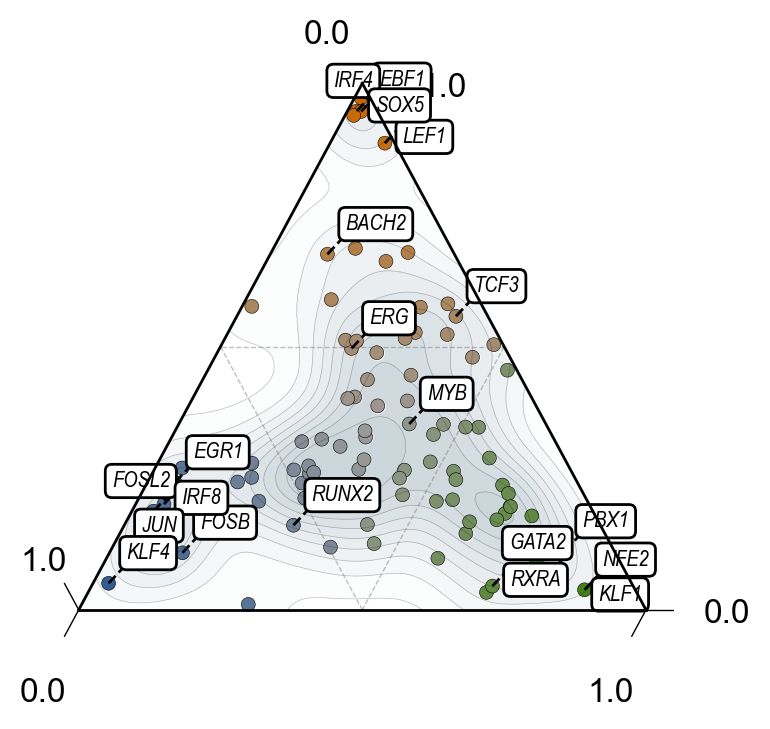

In [397]:
ternary_from_tf_df2(mlm_exp_df_norm, 
                    ["Ery", "NaiveB", "Mono"], 
                    n_pts=1000, label=[tf for tfs in tf_dict.values() for tf in tfs], 
                    noise_epsilon=0.02)
plt.savefig("./figures/tf_target_specificity_ternary.pdf", bbox_inches='tight', dpi=300)


### Scatterplot

<Axes: xlabel='diff_exp_logfc', ylabel='diff_mlm_logfc'>

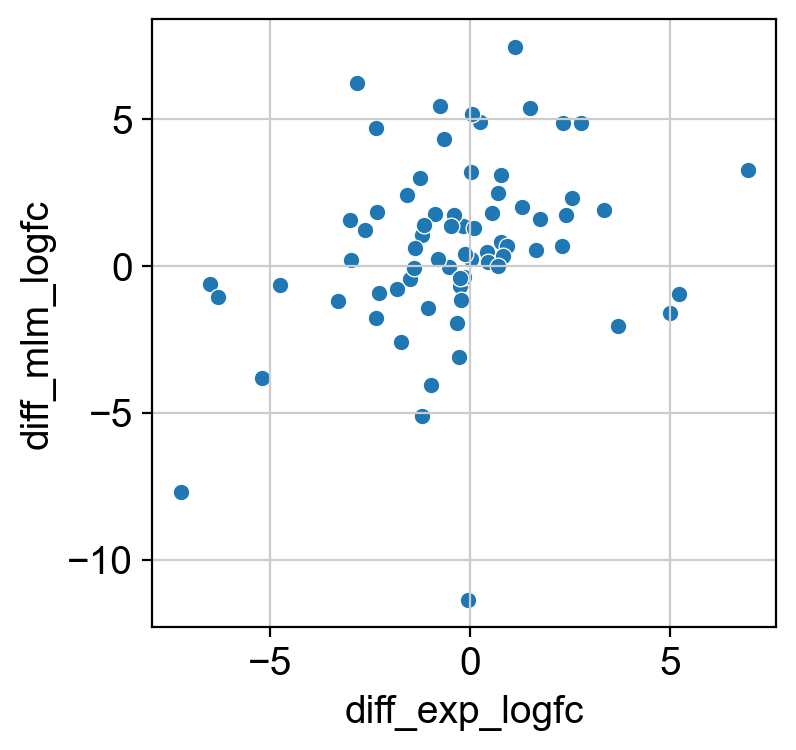

In [99]:
sns.scatterplot(x="diff_exp_logfc", y="diff_mlm_logfc", data=diff_df)

### Dumbbell Chart

In [193]:
mlmBE = pd.DataFrame(columns=["NaiveB_log_mlm","Ery_log_mlm"])
mlmBE["NaiveB_log_mlm"] = dfB["log_mlm_estimated"]
mlmBE["Ery_log_mlm"] = dfE["log_mlm_estimated"]

mlmBE["TF"] = mlmBE.index
mlmBE.index = range(mlmBE.shape[0])

In [204]:
mlmBE

,NaiveB_log_mlm,Ery_log_mlm,TF,Difference
23,1.201469,-4.222899,HIF1A,5.424368
14,-0.416917,-3.143001,ESR1,2.726084
28,-0.721607,-2.491073,JUN,1.769466
20,-1.215984,-2.080642,FOSL2,0.864659
30,1.451425,-2.009918,KLF12,3.461342
...,...,...,...,...
16,-0.073507,NaN,ETS2,NaN
66,-0.387138,NaN,TCF7L2,NaN
34,-2.965287,NaN,MECOM,NaN
43,NaN,NaN,NFIC,NaN


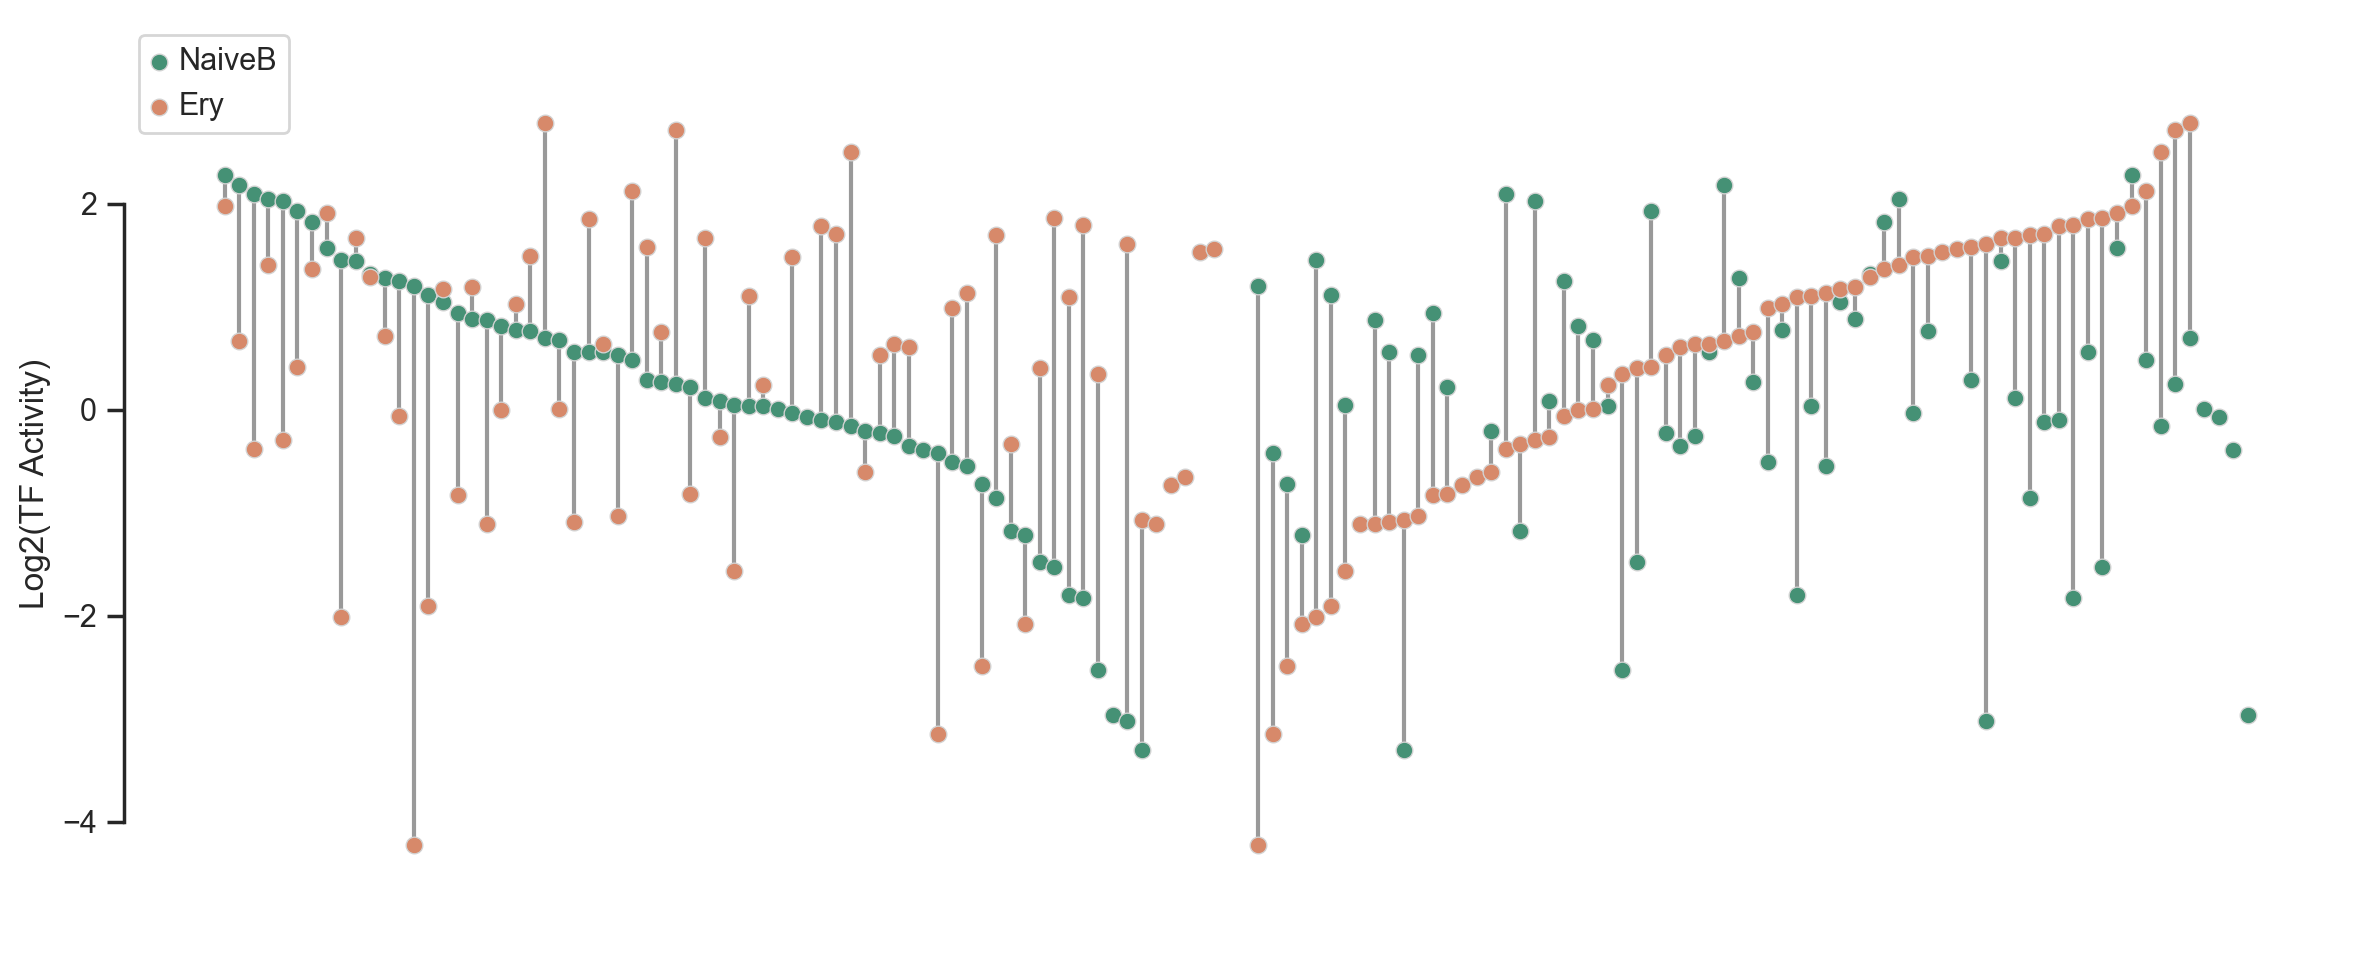

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

# 创建示例数据
df = mlmBE
# 按照NaiveB_log_mlm从大到小排序
# 计算差异

df['Difference'] = df['NaiveB_log_mlm'] - df['Ery_log_mlm']
dfl = df.sort_values(by='NaiveB_log_mlm', ascending=False)
dfr = df.sort_values(by='Ery_log_mlm', ascending=True)

dfc = pd.concat([dfl, dfr], axis=0, ignore_index=True)
dfc["sort"] = dfc.index
# 设置图形大小

fig, ax = plt.subplots(figsize=(12, 5), frameon=True)
for i, row in dfc.iterrows():
    ax.plot([row['sort'], row['sort']], [row['NaiveB_log_mlm'], row['Ery_log_mlm']], color='gray', alpha=0.8, zorder=1)
# 绘制NaiveB谱系的点
sns.scatterplot(x='sort', y='NaiveB_log_mlm', data=dfc, color='#459175', label='NaiveB', edgecolor='lightgray', ax=ax, zorder=2)

# 绘制Ery谱系的点
sns.scatterplot(x='sort', y='Ery_log_mlm', data=dfc, color='#D7896A', label='Ery', edgecolor='lightgray', ax=ax, zorder=2)

# 设置y轴范围
# plt.ylim(min(df['Ery_log_mlm'].min(), dfc['NaiveB_log_mlm'].min()) - 1, max(dfc['Ery_log_mlm'].max(), df['NaiveB_log_mlm'].max()) + 1)
ax.set_ylim(min(df['Ery_log_mlm'].min(), dfc['NaiveB_log_mlm'].min()) - 1, max(dfc['Ery_log_mlm'].max(), df['NaiveB_log_mlm'].max()) + 1)
# 设置y轴坐标轴线段
ax.set_ylabel('Log2(TF Activity)')
ax.set_xticks([])
ax.set_xlabel('')

sns.despine(trim=True, bottom=True, ax=ax)

fig.tight_layout()